# Supplier Cost Computation - Multiple Suppliers No REC Scenario

This notebook implements a comprehensive cost computation system for multiple suppliers in an energy market scenario without Renewable Energy Communities (REC). The analysis follows the energy market workflow from day-ahead forecasting to final customer billing.

## Overview
- **Scenario**: Multiple suppliers serving consumers and prosumers without REC structure
- **Market Sequence**: Day-ahead → Intra-day → Balancing Market → Supplier Billing (no REC settlement)
- **Data Source**: Consistent data from energy market operations in Austria (2016 data)
- **Suppliers**: Multiple suppliers with separate balancing groups

In [82]:
# Import necessary libraries
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(" Libraries imported successfully")
print(" Ready for supplier cost computation analysis")

 Libraries imported successfully
 Ready for supplier cost computation analysis


## Configuration and Data Loading

### Data Structure Documentation

Before loading the configuration, let's understand the data structure used in this analysis:

#### **Load Profiles (load_actual.csv, load_forecast_da.csv, load_forecast_id.csv)**

The load data contains **135 different load units** from the SimBench network `1-LV-urban6--2-no_sw`:

**Residential Loads:**
- `LV6.201 Load X [H0-A]` - Household type A profiles
- `LV6.201 Load X [H0-B]` - Household type B profiles
- `LV6.201 Load X [H0-C]` - Household type C profiles
- `LV6.201 Load X [H0-G]` - Household type G profiles
- `LV6.201 Load X [H0-L]` - Household type L profiles

**Commercial Loads:**
- `LV6.201 Load X [G1-A]`, `[G1-B]`, `[G1-C]` - Commercial type 1
- `LV6.201 Load X [G4-A]`, `[G4-B]` - Commercial type 4
- `LV6.201 Load X [G6-A]` - Commercial type 6

**Specialized Loads:**
- `LV6.201 Load X [HLS_A_3.7]`, `[HLS_B_3.7]`, `[HLS_C_3.7]` - Household Load Standard 3.7 kW
- `LV6.201 Load X [HLS_A_11.0]`, `[HLS_B_11.0]` - Household Load Standard 11.0 kW
- `LV6.201 Load X [APLS_A_50.0]`, `[APLS_B_11.0]` - Advanced Power Load Standard
- Heat pump profiles: `[Air_Alternative_2]`, `[Air_Parallel_2]`, `[Air_Semi-Parallel_2]`, `[Soil_Alternative_2]`

All loads are located on **Bus 201** of the LV6 network.

---

#### **Renewable Energy Sources (res_actual.csv, res_forecast_da.csv, res_forecast_id.csv)**

The RES data contains **12 solar PV units** from the SimBench network:

**Solar Photovoltaic (PV):**
- `LV6.201 SGen 1 [PV8]` - PV system type 8
- `LV6.201 SGen 2 [PV2]` - PV system type 2
- `LV6.201 SGen 3 [PV6]` - PV system type 6
- `LV6.201 SGen 4 [PV5]` - PV system type 5
- `LV6.201 SGen 5 [PV8]` - PV system type 8
- `LV6.201 SGen 6 [PV5]` - PV system type 5
- `LV6.201 SGen 7 [PV8]` - PV system type 8
- `LV6.201 SGen 8 [PV2]` - PV system type 2
- `LV6.201 SGen 9 [PV8]` - PV system type 8
- `LV6.201 SGen 10 [PV8]` - PV system type 8
- `LV6.201 SGen 11 [PV8]` - PV system type 8
- `LV6.201 SGen 12 [PV8]` - PV system type 8

All RES units are located on **Bus 201** of the LV6 network.

---

#### **Storage Systems (storage_actual.csv, storage_forecast_da.csv, storage_forecast_id.csv)**

The storage data contains **7 battery systems** paired with PV installations:

- `LV6.201 Storage 1 [Storage_PV5_H0-B]` - Battery paired with PV5 at household H0-B
- `LV6.201 Storage 2 [Storage_PV2_H0-A]` - Battery paired with PV2 at household H0-A
- `LV6.201 Storage 3 [Storage_PV8_H0-B]` - Battery paired with PV8 at household H0-B
- `LV6.201 Storage 4 [Storage_PV8_H0-L]` - Battery paired with PV8 at household H0-L
- `LV6.201 Storage 5 [Storage_PV8_H0-L]` - Battery paired with PV8 at household H0-L
- `LV6.201 Storage 6 [Storage_PV6_H0-B]` - Battery paired with PV6 at household H0-B
- `LV6.201 Storage 7 [Storage_PV8_H0-C]` - Battery paired with PV8 at household H0-C

All storage units are located on **Bus 201** of the LV6 network.

---

#### **Member Types in Configuration:**

**Consumers:**
- Contain **only load profiles**
- No generation capacity
- Pure energy buyers from suppliers
- Examples: households, commercial buildings

**Prosumers:**
- Contain **RES profiles** (renewable energy generation - PV)
- Can optionally have **load profiles** (energy consumption)
- Can optionally have **storage systems** (battery storage)
- Both consume and produce energy
- Examples: households with rooftop solar, commercial buildings with PV+storage

---

### Load JSON Configuration Templates
First, we load the JSON configurations that define the energy network structure, including suppliers, consumers, prosumers, and their relationships.


In [83]:
# Load B1 Multiple Suppliers No REC configuration
config_file = 'B1_multiple_supplier_no_rec.json'

try:
    with open(config_file, 'r') as f:
        config = json.load(f)
    print(f"Loaded configuration: {config_file}\n")
    
    # Display configuration summary
    print("="*80)
    print(" " * 25 + "SCENARIO CONFIGURATION")
    print("="*80)
    
    # System Information
    energy_system = config['energy_system']
    print(f"\nENERGY SYSTEM:")
    print(f"   - System ID: {energy_system['system_id']}")
    print(f"   - Name: {energy_system['system_name']}")
    print(f"   - Description: {energy_system['description']}")
    print(f"   - Location: {energy_system['location']['region']}, {energy_system['location']['country']}")
    print(f"   - Period: {energy_system['simulation_period']['start_date']} to {energy_system['simulation_period']['end_date']}")
    print(f"   - Timestep: {energy_system['simulation_period']['timestep']}")
    
    # Market Information
    energy_market = config['energy_market']
    print(f"\nENERGY MARKET:")
    print(f"   - Market ID: {energy_market['market_id']}")
    print(f"   - Market Name: {energy_market['market_name']}")
    print(f"   - Market Type: {energy_market['market_type']}")
    price_lists = energy_market['price_lists']
    print(f"   - Day-Ahead Prices: {price_lists['day_ahead_prices']['csv_file']}")
    print(f"   - Intraday Prices: {price_lists['intraday_prices']['csv_file']}")
    print(f"   - Grid Fees: {price_lists['grid_fees']['total_grid_fee_eur_per_kwh']} EUR/kWh")
    
    # Suppliers
    suppliers = config['suppliers']
    print(f"\nSUPPLIERS:")
    print(f"   - Total Suppliers: {len(suppliers)}")
    for supplier in suppliers:
        print(f"   • {supplier['supplier_id']}: {supplier['supplier_name']}")
        print(f"     - Balancing Group: {supplier['balancing_groups'][0]['balancing_group_id']}")
        print(f"     - Retail Pricing: {supplier['retail_pricing']['csv_file']} ({supplier['retail_pricing']['price']})")
        print(f"     - Feed-in Pricing: {supplier['feedin_pricing']['csv_file']} ({supplier['feedin_pricing']['price']})")
    
    # Prosumers and Consumers Distribution
    prosumers = config['prosumers']
    consumers = config['consumers']
    print(f"\nCUSTOMERS:")
    print(f"   - Total Prosumers: {len(prosumers)}")
    print(f"   - Total Consumers: {len(consumers)}")
    
    # Distribution by supplier
    for supplier in suppliers:
        supplier_id = supplier['supplier_id']
        prosumer_count = sum(1 for p in prosumers if p['supplier']['supplier_id'] == supplier_id)
        consumer_count = sum(1 for c in consumers if c['supplier']['supplier_id'] == supplier_id)
        print(f"   • {supplier_id}: {prosumer_count} prosumers + {consumer_count} consumers")
    
    # RECs
    recs = config['recs']
    print(f"\nRENEWABLE ENERGY COMMUNITIES:")
    print(f"   - Total RECs: {len(recs)}")
    if len(recs) == 0:
        print(f"   NO REC SCENARIO - Members trade individually with suppliers")
    
    # Settlement Approach
    settlement = config['settlement_approach']
    print(f"\nSETTLEMENT APPROACH:")
    print(f"   - Type: {settlement['type'].upper()}")
    print(f"   - Description: {settlement['description']}")
    print(f"   - Internal Sharing: {settlement['internal_sharing']}")
    print(f"   - REC Bonuses: {settlement['rec_bonuses']}")
    print(f"   - Balancing Responsibility: {settlement['balancing_responsibility']}")
    print(f"   - Settlement Basis: {settlement['metering']['settlement_basis']}")
    
    print("\n" + "="*80)
    print("Configuration loaded successfully")
    print("="*80 + "\n")
    
except FileNotFoundError:
    print(f"File not found: {config_file}")
    print("Please ensure the configuration file exists in the B_Scenarion_Forecasting directory.")
except json.JSONDecodeError as e:
    print(f"Invalid JSON in: {config_file}")
    print(f"Error: {str(e)}")
except Exception as e:
    print(f"Error loading {config_file}: {str(e)}")

Loaded configuration: B1_multiple_supplier_no_rec.json

                         SCENARIO CONFIGURATION

ENERGY SYSTEM:
   - System ID: ES_B1_MULTI_NOREC_001
   - Name: Multiple Suppliers without REC - Scenario B1
   - Description: 2 Suppliers serving consumers and prosumers independently. No REC structure. Each supplier manages their own balancing group with separate forecasting and settlement.
   - Location: Vienna, AT
   - Period: 2016-01-01 to 2016-12-31
   - Timestep: 15min

ENERGY MARKET:
   - Market ID: MARKET_001
   - Market Name: Austrian Energy Market
   - Market Type: day_ahead
   - Day-Ahead Prices: data/prices.csv
   - Intraday Prices: data/prices.csv
   - Grid Fees: 0.02 EUR/kWh

SUPPLIERS:
   - Total Suppliers: 2
   • SUP_A: Energy Supplier A
     - Balancing Group: BG_SUP_A_001
     - Retail Pricing: data/prices.csv (retail_price)
     - Feed-in Pricing: data/prices.csv (feedin_price)
   • SUP_B: Energy Supplier B
     - Balancing Group: BG_SUP_B_001
     - Retail Prici

## Data Loading

Load the energy system data including prices, loads, RES forecasts, and actual values.

**Price Data (prices.csv):**
```
datetime,DA_price,ID_price,imbalance_price,retail_price,feedin_price
```

- `datetime` - Timestamp for each 15-minute interval
- `DA_price` - Day-ahead market prices (EUR/MWh)
- `ID_price` - Intraday market prices (EUR/MWh)
- `imbalance_price` - Single imbalance price with sign indicating system state (EUR/MWh)
  - Negative: System has excess generation → surplus imbalances penalized, shortage imbalances rewarded
  - Positive: System has deficit → shortage imbalances penalized, surplus imbalances rewarded
  - Settlement = Imbalance_MWh × imbalance_price (sign automatically rewards helpful imbalances)
- `retail_price` - Fixed retail price for consumers (EUR/MWh)
- `feedin_price` - Fixed feed-in tariff for prosumer exports (EUR/MWh)

In [84]:
# Load energy system data from data directory
data_dir = Path('../data')  # Go up one level to data/data/

# Define data files
es_data_files = {
    'prices': 'prices.csv',
    'load_actual': 'load_actual.csv',
    'res_actual': 'res_actual.csv',
    'load_forecast_da': 'load_forecast_da.csv',
    'res_forecast_da': 'res_forecast_da.csv',
    'load_forecast_id': 'load_forecast_id.csv',
    'res_forecast_id': 'res_forecast_id.csv'
}

# Load all data
es_data = {}
print("LOADING ENERGY SYSTEM DATA")
print("="*80)
for name, filename in es_data_files.items():
    filepath = data_dir / filename
    try:
        df = pd.read_csv(filepath)
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
        es_data[name] = df
        print(f"Loaded {name}: {df.shape}")
    except FileNotFoundError:
        print(f"File not found: {filepath}")
    except Exception as e:
        print(f"Error loading {filepath}: {str(e)}")

print(f"\nTotal datasets loaded: {len(es_data)}")

# Display data structure
if 'prices' in es_data:
    prices_df = es_data['prices']
    print(f"\n📈 Prices:")
    print(f"   - Period: {prices_df.index.min()} to {prices_df.index.max()}")
    print(f"   - Columns: {list(prices_df.columns)}")
    print(f"   - Sample prices (EUR/MWh):")
    for col in prices_df.columns:
        print(f"     • {col}: {prices_df[col].mean():.2f} (avg)")

if 'load_forecast_da' in es_data:
    load_da_df = es_data['load_forecast_da']
    print(f"\n📊 Load Forecast DA:")
    print(f"   - Profiles: {len(load_da_df.columns)}")
    print(f"   - Sample columns: {list(load_da_df.columns[:5])}")

if 'res_forecast_da' in es_data:
    res_da_df = es_data['res_forecast_da']
    print(f"\n⚡ RES Forecast DA:")
    print(f"   - Profiles: {len(res_da_df.columns)}")
    print(f"   - Sample columns: {list(res_da_df.columns[:5])}")

print("="*80)


LOADING ENERGY SYSTEM DATA
Loaded prices: (35136, 5)
Loaded load_actual: (35136, 118)
Loaded res_actual: (35136, 17)
Loaded load_forecast_da: (35136, 118)
Loaded res_forecast_da: (35136, 17)
Loaded load_forecast_id: (35136, 118)
Loaded res_forecast_id: (35136, 17)

Total datasets loaded: 7

📈 Prices:
   - Period: 2016-01-01 00:00:00 to 2016-12-31 23:45:00
   - Columns: ['DA_price', 'ID_price', 'imbalance_price', 'retail_price', 'feedin_price']
   - Sample prices (EUR/MWh):
     • DA_price: 29.22 (avg)
     • ID_price: 29.22 (avg)
     • imbalance_price: 32.21 (avg)
     • retail_price: 201.00 (avg)
     • feedin_price: 82.40 (avg)

📊 Load Forecast DA:
   - Profiles: 118
   - Sample columns: ['LV3.101 Load 1 [H0-C]', 'LV3.101 Load 31 [H0-A]', 'LV3.101 Load 42 [H0-G]', 'LV3.101 Load 53 [H0-L]', 'LV3.101 Load 64 [H0-L]']

⚡ RES Forecast DA:
   - Profiles: 17
   - Sample columns: ['LV3.101 SGen 1 [PV7]', 'LV3.101 SGen 2 [PV3]', 'LV3.101 SGen 3 [PV3]', 'LV3.101 SGen 4 [PV4]', 'LV3.101 SGen 

## 1. Day-Ahead Market Operations

### 1.1 Day-Ahead Market Participation
Calculate day-ahead market positions for each balancing group based on aggregated forecasts of all members (consumers and prosumers).

**Aggregation Process:**
- Each balancing group aggregates (sums) load and RES forecasts from all assigned members
- Aggregated forecasts are submitted to the day-ahead market before gate closure
- Market positions are determined at the balancing group level, not individually

**Day-Ahead Market Commitments:**
- **DA Net Load Forecast (MWh)**: Net load to purchase from market = max(Σ load - Σ gen, 0) - Amount to purchase when in deficit (always ≥ 0)
- **DA Net Gen Forecast (MWh)**: Net generation to sell to market = max(Σ gen - Σ load, 0) - Amount to sell when in surplus (always ≥ 0)
- **DA Purchase Cost (EUR)**: Net Load × DA_price - Cost for purchasing energy (always ≥ 0)
- **DA Sale Revenue (EUR)**: Net Gen × DA_price - Revenue from selling energy (always ≥ 0)


In [85]:
def calculate_da_market_commitments(load_da_df, res_da_df, prices_df, config):
    """
    Calculate day-ahead market commitments and create energy system DataFrame
    
    Process:
    1. Aggregate DA forecasts by supplier and balancing group
    2. Calculate net position (gen - load)
    3. Split net position into separate purchase/sale commitments
    4. Return DataFrame with time-series data
    
    Net Position Logic:
    - Net position = sum_gen - sum_load
    - If net < 0 (deficit): need to purchase |net| from market
      * da_net_load_forecast_mwh = |net| (amount to purchase)
      * da_net_gen_forecast_mwh = 0
    - If net > 0 (surplus): can sell net to market
      * da_net_load_forecast_mwh = 0
      * da_net_gen_forecast_mwh = net (amount to sell)
    - If net = 0 (balanced): no market transaction needed
    
    Separate Purchase/Sale Accounting:
    - da_net_load_forecast_mwh: Net load to purchase from market (always ≥ 0)
    - da_net_gen_forecast_mwh: Net generation to sell to market (always ≥ 0)
    - da_purchase_commitment_eur: Cost for buying energy (always ≥ 0)
    - da_sale_commitment_eur: Revenue from selling energy (always ≥ 0)
    
    Returns DataFrame with columns: datetime, supplier_id, balancing_group_id,
    da_net_load_forecast_mwh, da_net_gen_forecast_mwh, da_price_eur_per_mwh,
    da_purchase_commitment_eur, da_sale_commitment_eur
    """
    # Step 1: Create aggregated forecast DataFrame
    da_forecast_df = pd.DataFrame(index=load_da_df.index)
    
    for supplier in config['suppliers']:
        supplier_id = supplier['supplier_id']
        
        for bg in supplier['balancing_groups']:
            bg_id = bg['balancing_group_id']
            
            # Initialize aggregated forecasts
            bg_load_total = pd.Series(0, index=da_forecast_df.index)
            bg_gen_total = pd.Series(0, index=da_forecast_df.index)
            
            # Aggregate prosumers in this balancing group
            for prosumer in config['prosumers']:
                if prosumer['supplier']['supplier_id'] == supplier_id and \
                   prosumer['supplier']['balancing_group_id'] == bg_id:
                    
                    # Add load forecast if exists
                    if 'load' in prosumer and prosumer['load']:
                        load_id = prosumer['load']['id']
                        if load_id in load_da_df.columns:
                            bg_load_total += load_da_df[load_id]
                    
                    # Add RES forecast if exists
                    if 'res' in prosumer and prosumer['res']:
                        res_id = prosumer['res']['id']
                        if res_id in res_da_df.columns:
                            bg_gen_total += res_da_df[res_id]
            
            # Aggregate consumers in this balancing group
            for consumer in config['consumers']:
                if consumer['supplier']['supplier_id'] == supplier_id and \
                   consumer['supplier']['balancing_group_id'] == bg_id:
                    
                    load_id = consumer['load']['id']
                    if load_id in load_da_df.columns:
                        bg_load_total += load_da_df[load_id]
            
            # Calculate net position (gen - load)
            net_position = bg_gen_total - bg_load_total
            
            # Split into purchase/sale based on net position sign
            # If deficit (net < 0): purchase = |net|, sale = 0
            # If surplus (net > 0): purchase = 0, sale = net
            bg_load_forecast = net_position.clip(upper=0).abs()  # max(0, -net) = purchase amount
            bg_gen_forecast = net_position.clip(lower=0)         # max(0, net) = sale amount
            
            # Add to DataFrame
            da_forecast_df[f"{bg_id}_load"] = bg_load_forecast
            da_forecast_df[f"{bg_id}_gen"] = bg_gen_forecast
    
    # Step 2: Calculate DA market transactions
    da_data_list = []
    
    for supplier in config['suppliers']:
        supplier_id = supplier['supplier_id']
        
        for bg in supplier['balancing_groups']:
            bg_id = bg['balancing_group_id']
            
            # Get forecasts for this balancing group
            da_load_forecast = da_forecast_df[f"{bg_id}_load"]
            da_gen_forecast = da_forecast_df[f"{bg_id}_gen"]
            
            # Get DA price
            da_price = prices_df['DA_price']
            
            # Calculate purchase cost and sale revenue separately
            # Purchase cost = load purchased from market
            # Sale revenue = generation sold to market
            purchase_cost_eur = da_load_forecast * da_price
            sale_revenue_eur = da_gen_forecast * da_price
            
            # Store time series data
            for timestamp in da_forecast_df.index:
                da_data_list.append({
                    'datetime': timestamp,
                    'supplier_id': supplier_id,
                    'balancing_group_id': bg_id,
                    'da_net_load_forecast_mwh': da_load_forecast.loc[timestamp],
                    'da_net_gen_forecast_mwh': da_gen_forecast.loc[timestamp],
                    'da_price_eur_per_mwh': da_price.loc[timestamp],
                    'da_purchase_commitment_eur': purchase_cost_eur.loc[timestamp],
                    'da_sale_commitment_eur': sale_revenue_eur.loc[timestamp]
                })
    
    # Create DataFrame
    es_timeseries_df = pd.DataFrame(da_data_list)
    
    return es_timeseries_df


In [86]:
# Calculate day-ahead market commitments and update es_timeseries_df
es_timeseries_df = calculate_da_market_commitments(
    load_da_df,
    res_da_df,
    prices_df,
    config
)

print("Sample of es_timeseries_df after DA market:")
display(es_timeseries_df.head())

Sample of es_timeseries_df after DA market:


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_price_eur_per_mwh,da_purchase_commitment_eur,da_sale_commitment_eur
0,2016-01-01 00:00:00,SUP_A,BG_SUP_A_001,0.011166,0.0,30.86,0.344583,0.0
1,2016-01-01 00:15:00,SUP_A,BG_SUP_A_001,0.004974,0.0,18.90,0.094009,0.0
2,2016-01-01 00:30:00,SUP_A,BG_SUP_A_001,0.006757,0.0,16.24,0.109734,0.0
3,2016-01-01 00:45:00,SUP_A,BG_SUP_A_001,0.006273,0.0,12.00,0.075276,0.0
4,2016-01-01 01:00:00,SUP_A,BG_SUP_A_001,0.005804,0.0,21.62,0.125482,0.0


### 1.2 Day-Ahead Market - Mathematical Formulation

This section documents the mathematical formulation of the **day-ahead market commitment mechanism** implemented in the `calculate_da_market_commitments()` function.

---

#### **Column Definitions and Mathematical Formulas**

The day-ahead market calculation creates the following columns in `es_timeseries_df`:

##### **1. Day-Ahead Net Position Split**

**Net Position Calculation:**
$$
Q_{\text{DA,net}}^{t} = Q_{\text{RES,DA}}^{t} - Q_{\text{load,DA}}^{t}
$$

Where:
- $Q_{\text{RES,DA}}^{t}$ = Aggregated RES generation forecast (MWh)
- $Q_{\text{load,DA}}^{t}$ = Aggregated load consumption forecast (MWh)

**Split into Separate Columns:**

`da_net_load_forecast_mwh` = Net load to purchase from market:
$$
Q_{\text{DA,net\_load}}^{t} = \max(-Q_{\text{DA,net}}^{t}, 0)
$$

`da_net_gen_forecast_mwh` = Net generation to sell to market:
$$
Q_{\text{DA,net\_gen}}^{t} = \max(Q_{\text{DA,net}}^{t}, 0)
$$

**Column Interpretation:**
- **da_net_load_forecast_mwh > 0**: DEFICIT position → BRP buys from market (da_net_gen = 0)
- **da_net_gen_forecast_mwh > 0**: SURPLUS position → BRP sells to market (da_net_load = 0)

---

##### **2. Day-Ahead Market Costs and Revenues**

**Purchase Commitment** (`da_purchase_commitment_eur`):
$$
C_{\text{DA,purchase}}^{t} = Q_{\text{DA,net\_load}}^{t} \times p_{\text{DA}}^{t}
$$

**Sale Commitment** (`da_sale_commitment_eur`):
$$
R_{\text{DA,sale}}^{t} = Q_{\text{DA,net\_gen}}^{t} \times p_{\text{DA}}^{t}
$$

Where:
- $p_{\text{DA}}^{t}$ = Day-ahead market price (EUR/MWh)
- Both cost and revenue are always ≥ 0

**Net Settlement** (for reference):
$$
S_{\text{DA,net}}^{t} = R_{\text{DA,sale}}^{t} - C_{\text{DA,purchase}}^{t}
$$

---

#### **Portfolio Aggregation**

Each balancing group aggregates multiple members:

**Total Load Forecast:**
$$
Q_{\text{load,DA}}^{t} = \sum_{i \in \text{prosumers}} Q_{\text{load},i}^{t} + \sum_{j \in \text{consumers}} Q_{\text{load},j}^{t}
$$

**Total RES Forecast:**
$$
Q_{\text{RES,DA}}^{t} = \sum_{i \in \text{prosumers}} Q_{\text{RES},i}^{t}
$$

**Portfolio Net Position (Split):**
$$
Q_{\text{DA,net}}^{t} = Q_{\text{RES,DA}}^{t} - Q_{\text{load,DA}}^{t}
$$

$$
Q_{\text{DA,net\_load}}^{t} = \max(-Q_{\text{DA,net}}^{t}, 0) \quad \text{(purchase)}
$$

$$
Q_{\text{DA,net\_gen}}^{t} = \max(Q_{\text{DA,net}}^{t}, 0) \quad \text{(sale)}
$$

---

#### **Connection to Subsequent Markets**

The day-ahead commitment serves as the **baseline** for all subsequent market operations:

1. **Intra-Day Market**: Adjust DA position based on updated forecasts
2. **Balancing Market**: Settle deviations from final committed position (DA + ID)
3. **Retail Billing**: Supplier's wholesale costs form basis for retail pricing


## 2. Intra-Day Market Operations

Calculate intra-day forecasts and adjustments from day-ahead commitments.

In [87]:
def calculate_id_market_adjustments(es_timeseries_df, load_forecast_id, res_forecast_id, prices_df, config):
    """
    Calculate intra-day market adjustments and add to energy system DataFrame
    
    Process:
    1. Aggregate ID forecasts by supplier and balancing group (total load and gen)
    2. Calculate ID net position and split into net load/gen (same as DA logic)
    3. Calculate adjustments from DA net commitments (extracted from es_timeseries_df)
    4. Add ID adjustment columns to es_timeseries_df
    
    ID Net Position Logic (builds from total forecasts):
    - Calculate: id_net = id_gen_total - id_load_total
    - Split: id_net_load = max(-id_net, 0), id_net_gen = max(id_net, 0)
    - Adjustment: change from DA net position (ID - DA)
    
    Columns Created:
    - id_net_load_forecast_mwh: Net load to purchase in ID market (always ≥ 0)
    - id_net_gen_forecast_mwh: Net generation to sell in ID market (always ≥ 0)
    - id_net_load_adjustment_mwh: Change in net load from DA (can be + or -)
    - id_net_gen_adjustment_mwh: Change in net gen from DA (can be + or -)
    - id_purchase_adjustment_eur: Additional purchase cost/savings (can be + or -)
    - id_sale_adjustment_eur: Additional sale revenue/reduction (can be + or -)
    - closing_net_load_forecast_mwh: Total net load position after ID (DA + ID adjustment)
    - closing_net_gen_forecast_mwh: Total net gen position after ID (DA + ID adjustment)
    
    Returns updated es_timeseries_df with ID adjustment columns added
    """
    # Step 1: Create ID forecast DataFrame by aggregating member forecasts
    id_forecast_df = pd.DataFrame(index=load_forecast_id.index)
    
    for supplier in config['suppliers']:
        supplier_id = supplier['supplier_id']
        
        for bg in supplier['balancing_groups']:
            bg_id = bg['balancing_group_id']
            
            # Initialize aggregated forecasts
            bg_load_forecast = pd.Series(0, index=id_forecast_df.index)
            bg_res_forecast = pd.Series(0, index=id_forecast_df.index)
            
            # Aggregate prosumers in this balancing group
            for prosumer in config['prosumers']:
                if prosumer['supplier']['supplier_id'] == supplier_id and \
                   prosumer['supplier']['balancing_group_id'] == bg_id:
                    
                    # Add load forecast if exists
                    if 'load' in prosumer and prosumer['load']:
                        load_id = prosumer['load']['id']
                        if load_id in load_forecast_id.columns:
                            bg_load_forecast += load_forecast_id[load_id]
                    
                    # Add RES forecast if exists
                    if 'res' in prosumer and prosumer['res']:
                        res_id = prosumer['res']['id']
                        if res_id in res_forecast_id.columns:
                            bg_res_forecast += res_forecast_id[res_id]
            
            # Aggregate consumers in this balancing group
            for consumer in config['consumers']:
                if consumer['supplier']['supplier_id'] == supplier_id and \
                   consumer['supplier']['balancing_group_id'] == bg_id:
                    
                    load_id = consumer['load']['id']
                    if load_id in load_forecast_id.columns:
                        bg_load_forecast += load_forecast_id[load_id]
            
            # Add to DataFrame
            id_forecast_df[f"{bg_id}_load"] = bg_load_forecast
            id_forecast_df[f"{bg_id}_res"] = bg_res_forecast
    
    # Step 2: Calculate ID adjustments and add to es_timeseries_df
    id_data_list = []
    
    for supplier in config['suppliers']:
        supplier_id = supplier['supplier_id']
        
        for bg in supplier['balancing_groups']:
            bg_id = bg['balancing_group_id']
            
            # Get DA forecasts from es_timeseries_df
            da_data = es_timeseries_df[
                (es_timeseries_df['supplier_id'] == supplier_id) & 
                (es_timeseries_df['balancing_group_id'] == bg_id)
            ].set_index('datetime')
            
            da_load_forecast = da_data['da_net_load_forecast_mwh']
            da_gen_forecast = da_data['da_net_gen_forecast_mwh']
            
            # Get ID total forecasts for this balancing group
            id_load_total = id_forecast_df[f"{bg_id}_load"]
            id_gen_total = id_forecast_df[f"{bg_id}_res"]
            
            # Calculate ID net position and split (same logic as DA)
            id_net_position = id_gen_total - id_load_total
            id_net_load_forecast = id_net_position.clip(upper=0).abs()  # max(0, -net)
            id_net_gen_forecast = id_net_position.clip(lower=0)         # max(0, net)
            
            # Calculate adjustments from DA net positions (ID - DA)
            load_adjustment = id_net_load_forecast - da_load_forecast
            gen_adjustment = id_net_gen_forecast - da_gen_forecast
            
            # Get ID prices
            id_price = prices_df['ID_price']
            
            # Calculate adjustment costs and revenues
            purchase_adjustment_eur = load_adjustment * id_price
            sale_adjustment_eur = gen_adjustment * id_price
            
            # Calculate closing net positions (DA + ID)
            closing_net_load = da_load_forecast + load_adjustment
            closing_net_gen = da_gen_forecast + gen_adjustment
            
            # Store time series data for merging
            for timestamp in id_forecast_df.index:
                id_data_list.append({
                    'datetime': timestamp,
                    'supplier_id': supplier_id,
                    'balancing_group_id': bg_id,
                    'id_net_load_forecast_mwh': id_net_load_forecast.loc[timestamp],
                    'id_net_gen_forecast_mwh': id_net_gen_forecast.loc[timestamp],
                    'id_net_load_adjustment_mwh': load_adjustment.loc[timestamp],
                    'id_net_gen_adjustment_mwh': gen_adjustment.loc[timestamp],
                    'id_price_eur_per_mwh': id_price.loc[timestamp],
                    'id_purchase_adjustment_eur': purchase_adjustment_eur.loc[timestamp],
                    'id_sale_adjustment_eur': sale_adjustment_eur.loc[timestamp],
                    'closing_net_load_forecast_mwh': closing_net_load.loc[timestamp],
                    'closing_net_gen_forecast_mwh': closing_net_gen.loc[timestamp]
                })
    
    # Create temporary DataFrame with ID data
    id_data_df = pd.DataFrame(id_data_list)
    
    # Drop any columns from id_data_df that already exist in es_timeseries_df
    # Keep only merge keys and new columns
    merge_keys = ['datetime', 'supplier_id', 'balancing_group_id']
    shared_columns = [col for col in id_data_df.columns 
                     if col in es_timeseries_df.columns and col not in merge_keys]
    
    if shared_columns:
        id_data_df = id_data_df.drop(columns=shared_columns)
    
    # Merge ID columns into es_timeseries_df
    es_timeseries_df = es_timeseries_df.merge(
        id_data_df,
        on=merge_keys,
        how='left'
    )
    
    # Calculate closing purchase and sale commitments (DA + ID)
    es_timeseries_df['closing_purchase_commitment_eur'] = (
        es_timeseries_df['da_purchase_commitment_eur'] + 
        es_timeseries_df['id_purchase_adjustment_eur']
    )
    es_timeseries_df['closing_sale_commitment_eur'] = (
        es_timeseries_df['da_sale_commitment_eur'] + 
        es_timeseries_df['id_sale_adjustment_eur']
    )
    
    return es_timeseries_df
    

# Calculate intra-day market adjustments and update es_timeseries_df
es_timeseries_df = calculate_id_market_adjustments(
    es_timeseries_df,
    es_data['load_forecast_id'],
    es_data['res_forecast_id'],
    es_data['prices'],
    config
)

# Display sample of time series data
display(es_timeseries_df.head())

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_price_eur_per_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_forecast_mwh,id_net_gen_forecast_mwh,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,id_purchase_adjustment_eur,id_sale_adjustment_eur,closing_net_load_forecast_mwh,closing_net_gen_forecast_mwh,closing_purchase_commitment_eur,closing_sale_commitment_eur
0,2016-01-01 00:00:00,SUP_A,BG_SUP_A_001,0.011166,0.0,30.86,0.344583,0.0,0.009371,0.0,-0.001795,0.0,30.09,-0.054012,0.0,0.009371,0.0,0.290571,0.0
1,2016-01-01 00:15:00,SUP_A,BG_SUP_A_001,0.004974,0.0,18.90,0.094009,0.0,0.005453,0.0,0.000479,0.0,20.60,0.009867,0.0,0.005453,0.0,0.103876,0.0
2,2016-01-01 00:30:00,SUP_A,BG_SUP_A_001,0.006757,0.0,16.24,0.109734,0.0,0.006588,0.0,-0.000169,0.0,16.99,-0.002871,0.0,0.006588,0.0,0.106862,0.0
3,2016-01-01 00:45:00,SUP_A,BG_SUP_A_001,0.006273,0.0,12.00,0.075276,0.0,0.005617,0.0,-0.000656,0.0,12.24,-0.008029,0.0,0.005617,0.0,0.067247,0.0
4,2016-01-01 01:00:00,SUP_A,BG_SUP_A_001,0.005804,0.0,21.62,0.125482,0.0,0.006056,0.0,0.000252,0.0,20.13,0.005073,0.0,0.006056,0.0,0.130555,0.0


### 2.1 Intra-Day Market - Mathematical Formulation

This section documents the mathematical formulation of the **intra-day market adjustment mechanism** implemented in the `calculate_id_market_adjustments()` function.

---

#### **Column Definitions and Mathematical Formulas**

The intra-day market calculation creates the following columns in `es_timeseries_df`:

##### **1. Intra-Day Net Position Split**

**Net Position Calculation (same as DA):**
$$
Q_{\text{ID,net}}^{t} = Q_{\text{RES,ID}}^{t} - Q_{\text{load,ID}}^{t}
$$

Where:
- $Q_{\text{RES,ID}}^{t}$ = Aggregated RES generation forecast (MWh)
- $Q_{\text{load,ID}}^{t}$ = Aggregated load consumption forecast (MWh)

**Split into Separate Columns:**

`id_net_load_forecast_mwh` = Net load to purchase from market:
$$
Q_{\text{ID,net\_load}}^{t} = \max(-Q_{\text{ID,net}}^{t}, 0)
$$

`id_net_gen_forecast_mwh` = Net generation to sell to market:
$$
Q_{\text{ID,net\_gen}}^{t} = \max(Q_{\text{ID,net}}^{t}, 0)
$$

---

##### **2. Intra-Day Adjustments from DA**

`id_net_load_adjustment_mwh` = Change in net load position:
$$
\Delta Q_{\text{net\_load}}^{t} = Q_{\text{ID,net\_load}}^{t} - Q_{\text{DA,net\_load}}^{t}
$$

`id_net_gen_adjustment_mwh` = Change in net generation position:
$$
\Delta Q_{\text{net\_gen}}^{t} = Q_{\text{ID,net\_gen}}^{t} - Q_{\text{DA,net\_gen}}^{t}
$$

**Adjustment Interpretation:**
- Positive: Need to buy/sell MORE than DA commitment
- Negative: Need to buy/sell LESS than DA commitment
- Adjustments can be positive or negative

---

##### **3. Intra-Day Adjustment Costs and Revenues**

`id_purchase_adjustment_eur` = Purchase adjustment cost/savings:
$$
C_{\text{ID,adj}}^{t} = \Delta Q_{\text{net\_load}}^{t} \times p_{\text{ID}}^{t}
$$

`id_sale_adjustment_eur` = Sale adjustment revenue/reduction:
$$
R_{\text{ID,adj}}^{t} = \Delta Q_{\text{net\_gen}}^{t} \times p_{\text{ID}}^{t}
$$

`id_net_adjustment_eur` = Net adjustment:

**Net Adjustment:**
$$
S_{\text{ID,net}}^{t} = R_{\text{ID,adj}}^{t} - C_{\text{ID,adj}}^{t}
$$

Where:
- $p_{\text{ID}}^{t}$ = Intra-day market price (EUR/MWh)
- Adjustments can be positive (cost/revenue) or negative (savings/reduction)

---

##### **4. Closing Commitments (DA + ID)**

**Closing Purchase Commitment:**
$$
C_{\text{closing,purchase}}^{t} = C_{\text{DA,purchase}}^{t} + C_{\text{ID,adj}}^{t}
$$

**Closing Sale Commitment:**
$$
R_{\text{closing,sale}}^{t} = R_{\text{DA,sale}}^{t} + R_{\text{ID,adj}}^{t}
$$

**Purpose:** Represents the BRP's total wholesale market commitment before real-time balancing.

---

#### **Connection to Balancing Market**

The closing commitments serve as the baseline for balancing market settlement:
- **Actual delivery** compared to **closing commitment**
- **Imbalance** = Actual - Closing
- Settled at balancing prices (penalty/reward mechanism)


## 3. Energy Community Settlement

### 3.1 REC Member Settlement (if applicable)
Since this is a "no REC" scenario, members are not part of a Renewable Energy Community. However, we'll compute what their position would be for comparison purposes.

In [88]:
# Since this is NO REC scenario, we skip internal REC settlement
# Members trade directly with their suppliers without community sharing

print(" Energy Community Settlement:")
print(" NO REC scenario - Members trade individually with their suppliers")
print(" - No internal energy sharing")
print(" - No REC bonuses or shared energy benefits")
print(" - Each member's imbalance is handled by their supplier's balancing group")
print("\n This section would be relevant in REC scenarios where:")
print(" - Members share locally generated renewable energy")
print(" - Community receives bonuses for self-consumption")
print(" - Internal settlement reduces grid dependencies")

 Energy Community Settlement:
 NO REC scenario - Members trade individually with their suppliers
 - No internal energy sharing
 - No REC bonuses or shared energy benefits
 - Each member's imbalance is handled by their supplier's balancing group

 This section would be relevant in REC scenarios where:
 - Members share locally generated renewable energy
 - Community receives bonuses for self-consumption
 - Internal settlement reduces grid dependencies


## 4. Balancing Market Operations

### 4.1 Calculate Actual Imbalances
Compare actual consumption/generation against intra-day forecasts to determine balancing requirements.

In [89]:
def calculate_balancing_market_positions(es_timeseries_df, load_actual_df, res_actual_df, prices_df, config):
    """
    Calculate balancing market positions, imbalances, and settlements using single imbalance price
    
    Process:
    1. Aggregate actual load and RES by supplier and balancing group
    2. Calculate BRP imbalances (Actual - ID Forecast)
    3. Apply single imbalance price with sign-based penalty/reward logic
    4. Add balancing columns to es_timeseries_df
    
    Balancing Group Perspective:
    - actual_load_mwh: Actual consumption (always ≥ 0)
    - actual_gen_mwh: Actual generation (always ≥ 0)
    - balancing_group_actual_mwh: Net position (load - gen), positive = deficit
    - balancing_group_forecast_mwh: Forecasted net position from ID market
    - imbalance_mwh: Deviation from forecast (actual - forecast)
    
    Imbalance Sign Convention:
    - POSITIVE imbalance: Actual deficit > forecast (need to buy more from balancing market)
    - NEGATIVE imbalance: Actual deficit < forecast (have surplus to sell to balancing market)
    
    Imbalance Price Sign Convention:
    - NEGATIVE imbalance price: System has EXCESS generation (supply > demand)
      * Generators are PENALIZED (receive negative price)
      * Consumers are REWARDED (pay negative price = receive money)
    
    - POSITIVE imbalance price: System has DEFICIT (supply < demand)
      * Generators are REWARDED (receive positive price)
      * Consumers are PENALIZED (pay positive price)
    
    Settlement Logic:
    Settlement = Imbalance × Imbalance_Price
    
    Examples:
    1. BRP surplus (+10 MWh) AND system excess (price = -50 EUR/MWh)
       → Settlement = +10 × (-50) = -500 EUR (BRP pays penalty)
    
    2. BRP surplus (+10 MWh) AND system deficit (price = +100 EUR/MWh)
       → Settlement = +10 × (+100) = +1000 EUR (BRP receives reward)
    
    3. BRP deficit (-10 MWh) AND system excess (price = -50 EUR/MWh)
       → Settlement = -10 × (-50) = +500 EUR (BRP receives reward)
    
    4. BRP deficit (-10 MWh) AND system deficit (price = +100 EUR/MWh)
       → Settlement = -10 × (+100) = -1000 EUR (BRP pays penalty)
    
    Returns updated es_timeseries_df with balancing columns added
    """
    # Step 1: Aggregate actual positions by supplier and balancing group
    balancing_data_list = []
    
    for supplier in config['suppliers']:
        supplier_id = supplier['supplier_id']
        
        for bg in supplier['balancing_groups']:
            bg_id = bg['balancing_group_id']
            
            # Initialize aggregated actuals
            bg_load_actual = pd.Series(0, index=load_actual_df.index)
            bg_res_actual = pd.Series(0, index=res_actual_df.index)
            
            # Aggregate prosumers in this balancing group
            for prosumer in config['prosumers']:
                if prosumer['supplier']['supplier_id'] == supplier_id and \
                   prosumer['supplier']['balancing_group_id'] == bg_id:
                    
                    # Add load actual if exists
                    if 'load' in prosumer and prosumer['load']:
                        load_id = prosumer['load']['id']
                        if load_id in load_actual_df.columns:
                            bg_load_actual += load_actual_df[load_id]
                    
                    # Add RES actual if exists
                    if 'res' in prosumer and prosumer['res']:
                        res_id = prosumer['res']['id']
                        if res_id in res_actual_df.columns:
                            bg_res_actual += res_actual_df[res_id]
            
            # Aggregate consumers in this balancing group
            for consumer in config['consumers']:
                if consumer['supplier']['supplier_id'] == supplier_id and \
                   consumer['supplier']['balancing_group_id'] == bg_id:
                    
                    load_id = consumer['load']['id']
                    if load_id in load_actual_df.columns:
                        bg_load_actual += load_actual_df[load_id]
            
            # Get ID net positions (closing commitments) from es_timeseries_df
            id_data = es_timeseries_df[
                (es_timeseries_df['supplier_id'] == supplier_id) & 
                (es_timeseries_df['balancing_group_id'] == bg_id)
            ].set_index('datetime')
            
            id_net_load_forecast = id_data['id_net_load_forecast_mwh']
            id_net_gen_forecast = id_data['id_net_gen_forecast_mwh']
            
            # Balancing Group Perspective: Supplier buys from market to serve customers
            # Actual position: positive = deficit (need to buy), negative = surplus (can sell)
            balancing_group_actual_mwh = bg_load_actual - bg_res_actual
            
            # Forecast position from ID market closing
            balancing_group_forecast_mwh = id_net_load_forecast - id_net_gen_forecast
            
            # Imbalance: Actual - Forecast
            # Positive = actual deficit > forecasted deficit (need to buy more)
            # Negative = actual deficit < forecasted deficit (have surplus to sell)
            imbalance_mwh = balancing_group_actual_mwh - balancing_group_forecast_mwh
            
            # Get imbalance price (sign indicates system position)
            imbalance_price = prices_df['imbalance_price']
            
            # Calculate settlement
            balancing_settlement = imbalance_mwh * imbalance_price
            
            # Split settlement into penalty and reward (both as positive amounts)
            # Penalty: when settlement is negative (BRP must pay)
            # Reward: when settlement is positive (BRP receives payment)
            imbalance_penalty = balancing_settlement.apply(lambda x: abs(x) if x < 0 else 0)
            imbalance_reward = balancing_settlement.apply(lambda x: x if x > 0 else 0)
            
            # Store time series data for merging
            for timestamp in load_actual_df.index:
                balancing_data_list.append({
                    'datetime': timestamp,
                    'supplier_id': supplier_id,
                    'balancing_group_id': bg_id,
                    'actual_load_mwh': bg_load_actual.loc[timestamp],
                    'actual_gen_mwh': bg_res_actual.loc[timestamp],
                    'balancing_group_actual_mwh': balancing_group_actual_mwh.loc[timestamp],
                    'balancing_group_forecast_mwh': balancing_group_forecast_mwh.loc[timestamp],
                    'imbalance_mwh': imbalance_mwh.loc[timestamp],
                    'imbalance_price_eur_per_mwh': imbalance_price.loc[timestamp],
                    'imbalance_penalty': imbalance_penalty.loc[timestamp],
                    'imbalance_reward': imbalance_reward.loc[timestamp]
                })
    
    # Create temporary DataFrame with balancing data
    balancing_data_df = pd.DataFrame(balancing_data_list)
    
    # Drop any columns from balancing_data_df that already exist in es_timeseries_df
    # Keep only merge keys and new columns
    merge_keys = ['datetime', 'supplier_id', 'balancing_group_id']
    shared_columns = [col for col in balancing_data_df.columns 
                     if col in es_timeseries_df.columns and col not in merge_keys]
    
    if shared_columns:
        balancing_data_df = balancing_data_df.drop(columns=shared_columns)
    
    # Merge balancing columns into es_timeseries_df
    es_timeseries_df = es_timeseries_df.merge(
        balancing_data_df,
        on=merge_keys,
        how='left'
    )
    
    return es_timeseries_df


# Calculate balancing market positions and update es_timeseries_df
es_timeseries_df = calculate_balancing_market_positions(
    es_timeseries_df,
    es_data['load_actual'],
    es_data['res_actual'],
    es_data['prices'],
    config
)

# Display sample of time series data
display(es_timeseries_df.head())

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_price_eur_per_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_forecast_mwh,id_net_gen_forecast_mwh,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,id_purchase_adjustment_eur,id_sale_adjustment_eur,closing_net_load_forecast_mwh,closing_net_gen_forecast_mwh,closing_purchase_commitment_eur,closing_sale_commitment_eur,actual_load_mwh,actual_gen_mwh,balancing_group_actual_mwh,balancing_group_forecast_mwh,imbalance_mwh,imbalance_price_eur_per_mwh,imbalance_penalty,imbalance_reward
0,2016-01-01 00:00:00,SUP_A,BG_SUP_A_001,0.011166,0.0,30.86,0.344583,0.0,0.009371,0.0,-0.001795,0.0,30.09,-0.054012,0.0,0.009371,0.0,0.290571,0.0,0.009220,0.0,0.009220,0.009371,-0.000151,57.52,0.008681,0.000000
1,2016-01-01 00:15:00,SUP_A,BG_SUP_A_001,0.004974,0.0,18.90,0.094009,0.0,0.005453,0.0,0.000479,0.0,20.60,0.009867,0.0,0.005453,0.0,0.103876,0.0,0.005272,0.0,0.005272,0.005453,-0.000181,5.93,0.001074,0.000000
2,2016-01-01 00:30:00,SUP_A,BG_SUP_A_001,0.006757,0.0,16.24,0.109734,0.0,0.006588,0.0,-0.000169,0.0,16.99,-0.002871,0.0,0.006588,0.0,0.106862,0.0,0.006382,0.0,0.006382,0.006588,-0.000206,6.63,0.001366,0.000000
3,2016-01-01 00:45:00,SUP_A,BG_SUP_A_001,0.006273,0.0,12.00,0.075276,0.0,0.005617,0.0,-0.000656,0.0,12.24,-0.008029,0.0,0.005617,0.0,0.067247,0.0,0.005979,0.0,0.005979,0.005617,0.000362,5.65,0.000000,0.002043
4,2016-01-01 01:00:00,SUP_A,BG_SUP_A_001,0.005804,0.0,21.62,0.125482,0.0,0.006056,0.0,0.000252,0.0,20.13,0.005073,0.0,0.006056,0.0,0.130555,0.0,0.005906,0.0,0.005906,0.006056,-0.000150,62.35,0.009361,0.000000


### 4.1 Balancing Market - Mathematical Formulation

This section documents the mathematical formulation of the **balancing market mechanism** implemented in the `calculate_balancing_market_positions()` function.

---

#### **Columns Created in `es_timeseries_df`:**

The balancing market calculation adds these columns:
- `actual_load_mwh`: Actual load (MWh, always ≥ 0)
- `actual_gen_mwh`: Actual generation (MWh, always ≥ 0)
- `balancing_group_actual_mwh`: Actual net position (load - gen, positive = deficit)
- `balancing_group_forecast_mwh`: Forecasted net position from ID market
- `imbalance_mwh`: Imbalance (actual - forecast, positive = need to buy)
- `imbalance_price_eur_per_mwh`: Imbalance price (EUR/MWh)
- `imbalance_penalty`: Penalty amount when BRP pays (EUR, always ≥ 0)
- `imbalance_reward`: Reward amount when BRP receives (EUR, always ≥ 0)

---

#### **Mathematical Formulas**

##### **1. Actual Net Position Split**

**Step 1: Calculate actual net position:**
$$
Q_{\text{actual,net}}^{t} = Q_{\text{gen,actual}}^{t} - Q_{\text{load,actual}}^{t}
$$

Where:
- $Q_{\text{gen,actual}}^{t}$ = Sum of actual generation from all members (MWh)
- $Q_{\text{load,actual}}^{t}$ = Sum of actual load from all members (MWh)

**Step 2: Split into separate columns (same logic as DA/ID):**

`actual_load_mwh` = Actual net load (deficit position):
$$
Q_{\text{actual,net\_load}}^{t} = \max(-Q_{\text{actual,net}}^{t}, 0)
$$

`actual_gen_mwh` = Actual net generation (surplus position):
$$
Q_{\text{actual,net\_gen}}^{t} = \max(Q_{\text{actual,net}}^{t}, 0)
$$

**Column Interpretation:**
- Only one is non-zero at each timestamp
- `actual_load_mwh` > 0: BRP consumed more than generated (net buyer)
- `actual_gen_mwh` > 0: BRP generated more than consumed (net seller)

---

##### **2. BRP Imbalances (Separate Load and Generation)**

`load_imbalance_mwh` = Deviation in load position:
$$
\Delta Q_{\text{load}}^{t} = Q_{\text{actual,net\_load}}^{t} - Q_{\text{ID,net\_load}}^{t}
$$

`gen_imbalance_mwh` = Deviation in generation position:
$$
\Delta Q_{\text{gen}}^{t} = Q_{\text{actual,net\_gen}}^{t} - Q_{\text{ID,net\_gen}}^{t}
$$

Where:
- $Q_{\text{ID,net\_load}}^{t}$ = ID net load forecast from `id_net_load_forecast_mwh`
- $Q_{\text{ID,net\_gen}}^{t}$ = ID net generation forecast from `id_net_gen_forecast_mwh`

**Imbalance Sign Convention:**
- **Positive**: Actual > Forecast (more load/gen than committed)
- **Negative**: Actual < Forecast (less load/gen than committed)
- Both can be non-zero simultaneously (e.g., over-consumed AND under-generated)

---

##### **3. Net Imbalance for Settlement Calculation**

**Combined net imbalance (internal calculation, not stored):**
$$
\Delta Q_{\text{net}}^{t} = \Delta Q_{\text{gen}}^{t} - \Delta Q_{\text{load}}^{t}
$$

**Interpretation:**
- **Positive net imbalance**: BRP has surplus (more gen or less load than committed)
- **Negative net imbalance**: BRP has deficit (less gen or more load than committed)

---

##### **4. Imbalance Price** (`imbalance_price_eur_per_mwh`)

$$
p_{\text{imbalance}}^{t} \quad \text{(EUR/MWh)}
$$

**Single-Price Mechanism with Sign-Based Settlement:**

The **sign of the imbalance price** indicates **system state**:

**NEGATIVE price** ($p_{\text{imbalance}}^{t} < 0$): System has **EXCESS generation**
- Too much supply relative to demand
- TSO wants to discourage generation, encourage consumption

**POSITIVE price** ($p_{\text{imbalance}}^{t} > 0$): System has **DEFICIT**
- Too little supply relative to demand  
- TSO wants to encourage generation, discourage consumption

**Economic Logic:**
- Price sign encodes system needs
- Settlement = imbalance × price automatically rewards helpful behavior
- No need for separate penalty/reward prices

---

##### **5. Balancing Settlement and Penalty/Reward Split**

**Step 1: Calculate net imbalance and settlement:**
$$
\Delta Q_{\text{net}}^{t} = \Delta Q_{\text{gen}}^{t} - \Delta Q_{\text{load}}^{t}
$$

$$
S_{\text{balancing}}^{t} = \Delta Q_{\text{net}}^{t} \times p_{\text{imbalance}}^{t}
$$

**Step 2: Split settlement into penalty and reward:**

Both columns are stored as **positive amounts** for clarity:

`imbalance_penalty` (always ≥ 0):
$$
\text{imbalance\_penalty}^{t} = \begin{cases}
|S_{\text{balancing}}^{t}| & \text{if } S_{\text{balancing}}^{t} < 0 \\
0 & \text{otherwise}
\end{cases}
$$

`imbalance_reward` (always ≥ 0):
$$
\text{imbalance\_reward}^{t} = \begin{cases}
S_{\text{balancing}}^{t} & \text{if } S_{\text{balancing}}^{t} > 0 \\
0 & \text{otherwise}
\end{cases}
$$

**Key Point:** Only one is non-zero at each timestamp:
- Negative settlement → `imbalance_penalty` = |settlement|, `imbalance_reward` = 0
- Positive settlement → `imbalance_penalty` = 0, `imbalance_reward` = settlement

**Settlement Logic - How Penalty/Reward is Determined:**

| `balancing_group_actual_mwh` | `balancing_group_forecast_mwh` | `imbalance_mwh` | Price | System | Settlement | `imbalance_penalty` | `imbalance_reward` |
|---------------------|----------------------|----------|-------|--------|------------|---------------------|-------------------|
| +10 | 0 | +10 | -50 | Excess | -500 | **500** | 0 |
| +10 | 0 | +10 | +100 | Deficit | +1000 | 0 | **1000** |
| 0 | +10 | -10 | -50 | Excess | +500 | 0 | **500** |
| 0 | +10 | -10 | +100 | Deficit | -1000 | **1000** | 0 |
| -5 | 0 | -5 | -50 | Excess | +250 | 0 | **250** |
| -5 | 0 | -5 | +100 | Deficit | -500 | **500** | 0 |
| 0 | -8 | +8 | -50 | Excess | -400 | **400** | 0 |
| 0 | -8 | +8 | +100 | Deficit | +800 | 0 | **800** |

**Interpretation Guide:**

**When System has EXCESS (price < 0):**
- Over-generating (`gen_imbalance` > 0) → Worsens excess → **PENALTY**
- Under-generating (`gen_imbalance` < 0) → Helps reduce excess → **REWARD**
- Over-consuming (`load_imbalance` > 0) → Absorbs excess → **REWARD**
- Under-consuming (`load_imbalance` < 0) → Worsens excess → **PENALTY**

**When System has DEFICIT (price > 0):**
- Over-generating (`gen_imbalance` > 0) → Helps meet demand → **REWARD**
- Under-generating (`gen_imbalance` < 0) → Worsens shortage → **PENALTY**
- Over-consuming (`load_imbalance` > 0) → Increases demand → **PENALTY**
- Under-consuming (`load_imbalance` < 0) → Reduces demand → **REWARD**

**The Math Automatically Determines Penalty/Reward:**
1. Imbalance = `balancing_group_actual_mwh` - `balancing_group_forecast_mwh`
2. Settlement = `imbalance_mwh` × `imbalance_price_eur_per_mwh`
3. If settlement < 0 → `imbalance_penalty` = |settlement|
4. If settlement > 0 → `imbalance_reward` = settlement

---

#### **Complete Accounting Flow**

**Net Settlement Calculation** (for reference, not in output):
$$
S_{\text{net,balancing}}^{t} = R_{\text{reward}}^{t} - P_{\text{penalty}}^{t}
$$

Where only one of penalty or reward is non-zero at each timestamp.

---

#### **Implementation Notes**

1. **Aggregation Level**: Calculations performed at **balancing group** level for each supplier
2. **Time Resolution**: 15-minute intervals (all timestamps from actual data)
3. **Price Source**: `imbalance_price_eur_per_mwh` from `prices.csv`
4. **Columns Stored**: `balancing_group_actual_mwh`, `balancing_group_forecast_mwh`, `imbalance_mwh`, `imbalance_price_eur_per_mwh`, `imbalance_penalty`, `imbalance_reward`
5. **Data Flow**:
   ```
   Actual Data → Aggregate by BG → Split Actual into Net Load/Gen → 
   Calculate Imbalances (Actual - ID) → Compute Net Imbalance →
   Apply Imbalance Price → Split Settlement into Penalty/Reward
   ```
6. **Sign Convention**: 
   - `balancing_group_actual_mwh`, `balancing_group_forecast_mwh`, and `imbalance_mwh` can be positive or negative
   - `imbalance_penalty` and `imbalance_reward` are always ≥ 0
   - Only one of penalty/reward is non-zero at each timestamp

---


## 5. Retail Billing (Customer Level)

### 5.1 Calculate Customer Bills

Calculate retail billing for each individual customer (prosumers and consumers).

In [90]:
def calculate_customer_bills(config, load_actual_df, res_actual_df, prices_df):
    """
    Calculate customer-level billing with retail prices.
    
    Args:
        config: Configuration dictionary with prosumers and consumers
        load_actual_df: Actual load data
        res_actual_df: Actual RES generation data
        prices_df: Prices dataframe with retail_price and feedin_price columns
    
    Returns:
        pd.DataFrame: Customer-level billing dataframe with columns:
            - datetime, supplier_id, balancing_group_id, customer_id, customer_type
            - actual_load_mwh, actual_gen_mwh, net_load_mwh
            - retail_price_eur_per_mwh, feedin_price_eur_per_mwh
            - sales_revenue_eur: Revenue from selling to customer
            - purchase_costs_eur: Cost of buying from customer
    """
    retail_price = prices_df['retail_price']
    feedin_price = prices_df['feedin_price'] 
    
    all_records = []
    
    # Process prosumers (load + generation)
    for prosumer in config['prosumers']:
        customer_id = prosumer['meter_id']
        supplier_id = prosumer['supplier']['supplier_id']
        bg_id = prosumer['supplier']['balancing_group_id']
        
        # Get actual generation
        res_id = prosumer['res']['id']
        if res_id in res_actual_df.columns:
            actual_gen = res_actual_df[res_id]
        else:
            # Fallback: use first available generation column
            gen_cols = [col for col in res_actual_df.columns if col != 'datetime']
            if gen_cols:
                actual_gen = res_actual_df[gen_cols[0]]
                print(f"Warning: Generation ID '{res_id}' not found for {customer_id}, using '{gen_cols[0]}'")
            else:
                actual_gen = pd.Series(0.0, index=res_actual_df.index)
        
        # Get actual load (if prosumer has load)
        actual_load = None
        if 'load' in prosumer:
            load_id = prosumer['load']['id']
            if load_id in load_actual_df.columns:
                actual_load = load_actual_df[load_id]
            else:
                # Fallback: use first available load column
                load_cols = [col for col in load_actual_df.columns if col != 'datetime']
                if load_cols:
                    actual_load = load_actual_df[load_cols[0]]
                    print(f"Warning: Load ID '{load_id}' not found for {customer_id}, using '{load_cols[0]}'")
        
        if actual_load is None:
            actual_load = pd.Series(0.0, index=res_actual_df.index)
        
        # Net load (positive = import, negative = export)
        net_load = actual_load - actual_gen
        grid_import = net_load.clip(lower=0)
        grid_export = (-net_load).clip(lower=0)
        
        # Calculate billing
        sales_revenue = grid_import * retail_price  # Supplier sells to customer
        purchase_costs = grid_export * feedin_price  # Supplier buys from customer
        
        # Ensure no negative zeros
        sales_revenue = sales_revenue.abs()
        purchase_costs = purchase_costs.abs()
        
        # Create dataframe for this customer
        customer_df = pd.DataFrame({
            'datetime': prices_df.index,
            'supplier_id': supplier_id,
            'balancing_group_id': bg_id,
            'customer_id': customer_id,
            'customer_type': 'prosumer',
            'actual_load_mwh': actual_load.values,
            'actual_gen_mwh': actual_gen.values,
            'net_load_mwh': net_load.values,
            'retail_price_eur_per_mwh': retail_price.values,
            'feedin_price_eur_per_mwh': feedin_price.values,
            'sales_revenue_eur': sales_revenue.values,
            'purchase_costs_eur': purchase_costs.values
        })
        
        all_records.append(customer_df)
    
    # Process consumers (only load, no RES)
    for consumer in config['consumers']:
        customer_id = consumer['meter_id']
        supplier_id = consumer['supplier']['supplier_id']
        bg_id = consumer['supplier']['balancing_group_id']
        
        # Get actual load
        load_id = consumer['load']['id']
        if load_id in load_actual_df.columns:
            actual_load = load_actual_df[load_id]
        else:
            # Fallback: use first available load column
            load_cols = [col for col in load_actual_df.columns if col != 'datetime']
            if load_cols:
                actual_load = load_actual_df[load_cols[0]]
                print(f"Warning: Load ID '{load_id}' not found for {customer_id}, using '{load_cols[0]}'")
            else:
                actual_load = pd.Series(0.0, index=load_actual_df.index)
        
        # No generation for consumers
        actual_gen = pd.Series(0.0, index=actual_load.index)
        net_load = actual_load  # All load is imported
        
        # Calculate billing (only sales, no purchases from consumer)
        sales_revenue = actual_load * retail_price
        purchase_costs = pd.Series(0.0, index=actual_load.index)  # Use Series with 0.0 instead of multiplication
        
        # Create dataframe for this customer
        customer_df = pd.DataFrame({
            'datetime': prices_df.index,
            'supplier_id': supplier_id,
            'balancing_group_id': bg_id,
            'customer_id': customer_id,
            'customer_type': 'consumer',
            'actual_load_mwh': actual_load.values,
            'actual_gen_mwh': actual_gen.values,
            'net_load_mwh': net_load.values,
            'retail_price_eur_per_mwh': retail_price.values,
            'feedin_price_eur_per_mwh': feedin_price.values,
            'sales_revenue_eur': sales_revenue.values,
            'purchase_costs_eur': purchase_costs.values
        })
        
        all_records.append(customer_df)
    
    # Concatenate all customer records
    customer_billing_df = pd.concat(all_records, ignore_index=True)
    
    return customer_billing_df

# Calculate customer bills
customer_billing_df = calculate_customer_bills(
    config,
    es_data['load_actual'],
    es_data['res_actual'],
    es_data['prices']
)


# Display sample of time series data
display(customer_billing_df.head(10))

,datetime,supplier_id,balancing_group_id,customer_id,customer_type,actual_load_mwh,actual_gen_mwh,net_load_mwh,retail_price_eur_per_mwh,feedin_price_eur_per_mwh,sales_revenue_eur,purchase_costs_eur
0,2016-01-01 00:00:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002915,0.0,0.002915,201.0,82.4,0.585983,0.0
1,2016-01-01 00:15:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002741,0.0,0.002741,201.0,82.4,0.550918,0.0
2,2016-01-01 00:30:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002974,0.0,0.002974,201.0,82.4,0.597797,0.0
3,2016-01-01 00:45:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002764,0.0,0.002764,201.0,82.4,0.555607,0.0
4,2016-01-01 01:00:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.003079,0.0,0.003079,201.0,82.4,0.618799,0.0
5,2016-01-01 01:15:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002799,0.0,0.002799,201.0,82.4,0.562544,0.0
6,2016-01-01 01:30:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.003067,0.0,0.003067,201.0,82.4,0.616548,0.0
7,2016-01-01 01:45:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002799,0.0,0.002799,201.0,82.4,0.562544,0.0
8,2016-01-01 02:00:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.003161,0.0,0.003161,201.0,82.4,0.635299,0.0
9,2016-01-01 02:15:00,SUP_B,BG_SUP_B_001,prosumer_001,prosumer,0.002764,0.0,0.002764,201.0,82.4,0.555607,0.0


### 5.2 Aggregate Customer Bills to Balancing Group Level

Aggregate customer billing to balancing group level and merge with wholesale market data.

In [91]:
# First, aggregate customer billing to balancing group level (timeseries)
retail_bg_df = customer_billing_df.groupby(['datetime', 'supplier_id', 'balancing_group_id']).agg({
    'retail_price_eur_per_mwh': 'mean',
    'feedin_price_eur_per_mwh': 'mean',
    'sales_revenue_eur': 'sum',
    'purchase_costs_eur': 'sum'
}).reset_index()

# Remove any existing retail columns from es_timeseries_df
retail_cols_to_drop = [col for col in es_timeseries_df.columns 
                       if col in ['retail_price_eur_per_mwh', 'feedin_price_eur_per_mwh', 
                                  'sales_revenue_eur', 'purchase_costs_eur'] 
                       or '_x' in col or '_y' in col]
if retail_cols_to_drop:
    es_timeseries_df = es_timeseries_df.drop(columns=retail_cols_to_drop)

# Merge retail billing into es_timeseries_df
es_timeseries_df = es_timeseries_df.merge(
    retail_bg_df,
    on=['datetime', 'supplier_id', 'balancing_group_id'],
    how='left'
)

print(f"\nRetail billing merged into es_timeseries_df")
print(f"   Shape: {es_timeseries_df.shape}")

# Now aggregate combined data to monthly level by balancing group
es_timeseries_copy = es_timeseries_df.copy()
es_timeseries_copy['month_year'] = pd.to_datetime(es_timeseries_copy['datetime']).dt.strftime('%m-%Y')

# Define aggregation logic
numeric_columns = es_timeseries_copy.select_dtypes(include=[np.number]).columns.tolist()
agg_dict = {}
for col in numeric_columns:
    if 'price' in col.lower():
        agg_dict[col] = 'mean'  # Average prices
    else:
        agg_dict[col] = 'sum'   # Sum quantities and currencies

# Aggregate to monthly by balancing group
monthly_bg_df = es_timeseries_copy.groupby(
    ['month_year', 'supplier_id', 'balancing_group_id']
).agg(agg_dict).reset_index()

# Rename month_year to datetime
monthly_bg_df = monthly_bg_df.rename(columns={'month_year': 'datetime'})

print(f"\nMonthly aggregation by balancing group created:")
print(f"   Shape: {monthly_bg_df.shape}")
print(f"   Months: {monthly_bg_df['datetime'].nunique()}")
print(f"   Supplier-BG combinations: {len(monthly_bg_df[['supplier_id', 'balancing_group_id']].drop_duplicates())}")
print(f"\nSample columns: {monthly_bg_df.columns.tolist()[:10]}...")

display(monthly_bg_df.head())


Retail billing merged into es_timeseries_df
   Shape: (70272, 31)

Monthly aggregation by balancing group created:
   Shape: (24, 31)
   Months: 12
   Supplier-BG combinations: 2

Sample columns: ['datetime', 'supplier_id', 'balancing_group_id', 'da_net_load_forecast_mwh', 'da_net_gen_forecast_mwh', 'da_price_eur_per_mwh', 'da_purchase_commitment_eur', 'da_sale_commitment_eur', 'id_net_load_forecast_mwh', 'id_net_gen_forecast_mwh']...


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_price_eur_per_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_forecast_mwh,id_net_gen_forecast_mwh,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,id_purchase_adjustment_eur,id_sale_adjustment_eur,closing_net_load_forecast_mwh,closing_net_gen_forecast_mwh,closing_purchase_commitment_eur,closing_sale_commitment_eur,actual_load_mwh,actual_gen_mwh,balancing_group_actual_mwh,balancing_group_forecast_mwh,imbalance_mwh,imbalance_price_eur_per_mwh,imbalance_penalty,imbalance_reward,retail_price_eur_per_mwh,feedin_price_eur_per_mwh,sales_revenue_eur,purchase_costs_eur
0,01-2016,SUP_A,BG_SUP_A_001,35.309781,0.000000,29.587103,1163.150484,0.000000,32.148344,0.000000,-3.161437,0.000000,29.578424,-104.179821,0.000000,32.148344,0.000000,1058.970664,0.000000,32.113559,0.000000,32.113559,32.148344,-0.034785,43.178360,27.799361,24.882361,201.0,82.4,6454.825273,0.000000
1,01-2016,SUP_B,BG_SUP_B_001,8.987278,0.031913,29.587103,288.515455,1.230059,8.066068,0.048044,-0.921210,0.016131,29.578424,-29.368520,0.564629,8.066068,0.048044,259.146936,1.794688,9.142619,1.122423,8.020196,8.018024,0.002172,43.178360,8.238655,7.973238,201.0,82.4,1687.804959,31.051918
2,02-2016,SUP_A,BG_SUP_A_001,32.889510,0.000000,22.440036,830.578111,0.000000,29.943661,0.000000,-2.945849,0.000000,22.414494,-74.481772,0.000000,29.943661,0.000000,756.096338,0.000000,29.923694,0.000000,29.923694,29.943661,-0.019967,26.566688,18.627634,17.845430,201.0,82.4,6014.662458,0.000000
3,02-2016,SUP_B,BG_SUP_B_001,9.082947,0.048691,22.440036,221.959729,1.038068,8.079405,0.068100,-1.003542,0.019409,22.414494,-24.833520,0.435111,8.079405,0.068100,197.126209,1.473179,9.925348,1.893557,8.031791,8.011305,0.020486,26.566688,6.655084,7.716394,201.0,82.4,1772.561889,64.842626
4,03-2016,SUP_A,BG_SUP_A_001,30.582397,0.000000,24.100847,791.790547,0.000000,27.829092,0.000000,-2.753305,0.000000,24.054382,-71.870037,0.000000,27.829092,0.000000,719.920511,0.000000,27.849258,0.000000,27.849258,27.829092,0.020166,18.326912,17.513385,16.767735,201.0,82.4,5597.700841,0.000000


### 5.3 Monthly Aggregation

Aggregate the complete energy system dataframe (with retail billing) to monthly level.

In [92]:
# Create monthly aggregation for complete energy system dataframe
es_timeseries_df_copy = es_timeseries_df.copy()

# Convert datetime to "MM-YYYY" format (e.g., "01-2016", "02-2016")
es_timeseries_df_copy['month_year'] = pd.to_datetime(es_timeseries_df_copy['datetime']).dt.strftime('%m-%Y')

# Define aggregation logic: mean for prices, sum for quantities and currencies
numeric_columns = es_timeseries_df_copy.select_dtypes(include=[np.number]).columns.tolist()

agg_dict = {}
for col in numeric_columns:
    if 'price' in col.lower():
        agg_dict[col] = 'mean'  # Average prices
    else:
        agg_dict[col] = 'sum'   # Sum quantities and currencies

# Group by month, supplier_id, and balancing_group_id
es_monthly_df = es_timeseries_df_copy.groupby(['month_year', 'supplier_id', 'balancing_group_id']).agg(agg_dict).reset_index()

# Rename month_year to datetime for consistency
es_monthly_df = es_monthly_df.rename(columns={'month_year': 'datetime'})

# Select columns to keep in final output
columns_to_keep = [
    'datetime', 'supplier_id', 'balancing_group_id',
    # Day-ahead market
    'da_net_load_forecast_mwh', 'da_net_gen_forecast_mwh',
    'da_purchase_commitment_eur', 'da_sale_commitment_eur',
    # Intraday market
    'id_net_load_adjustment_mwh', 'id_net_gen_adjustment_mwh', 'id_price_eur_per_mwh',
    'id_purchase_adjustment_eur', 'id_sale_adjustment_eur',
    'closing_purchase_commitment_eur', 'closing_sale_commitment_eur',
    # Balancing market
    'actual_load_mwh', 'actual_gen_mwh',
    'balancing_group_actual_mwh', 'balancing_group_forecast_mwh', 'imbalance_mwh',
    'imbalance_price_eur_per_mwh', 'imbalance_penalty', 'imbalance_reward',
    # Retail billing
    'retail_price_eur_per_mwh', 'feedin_price_eur_per_mwh',
    'sales_revenue_eur', 'purchase_costs_eur'
]

# Keep only the columns that exist in the dataframe
columns_to_keep = [col for col in columns_to_keep if col in es_monthly_df.columns]
es_monthly_df = es_monthly_df[columns_to_keep]

print(f"✅ Monthly aggregation created: {es_monthly_df.shape}")
print(f"   Months: {es_monthly_df['datetime'].nunique()}")
print(f"   Supplier-BG combinations: {es_monthly_df.groupby(['supplier_id', 'balancing_group_id']).ngroups}")
print(f"\n   Columns included: {es_monthly_df.columns.tolist()}")

# Verify retail billing columns
retail_cols = ['sales_revenue_eur', 'purchase_costs_eur']
missing_cols = [col for col in retail_cols if col not in es_monthly_df.columns]
if missing_cols:
    print(f"\n   Missing columns: {missing_cols}")
else:
    print(f"   All retail billing columns present")

display(es_monthly_df)

✅ Monthly aggregation created: (24, 26)
   Months: 12
   Supplier-BG combinations: 2

   Columns included: ['datetime', 'supplier_id', 'balancing_group_id', 'da_net_load_forecast_mwh', 'da_net_gen_forecast_mwh', 'da_purchase_commitment_eur', 'da_sale_commitment_eur', 'id_net_load_adjustment_mwh', 'id_net_gen_adjustment_mwh', 'id_price_eur_per_mwh', 'id_purchase_adjustment_eur', 'id_sale_adjustment_eur', 'closing_purchase_commitment_eur', 'closing_sale_commitment_eur', 'actual_load_mwh', 'actual_gen_mwh', 'balancing_group_actual_mwh', 'balancing_group_forecast_mwh', 'imbalance_mwh', 'imbalance_price_eur_per_mwh', 'imbalance_penalty', 'imbalance_reward', 'retail_price_eur_per_mwh', 'feedin_price_eur_per_mwh', 'sales_revenue_eur', 'purchase_costs_eur']
   All retail billing columns present


,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,id_purchase_adjustment_eur,id_sale_adjustment_eur,closing_purchase_commitment_eur,closing_sale_commitment_eur,actual_load_mwh,actual_gen_mwh,balancing_group_actual_mwh,balancing_group_forecast_mwh,imbalance_mwh,imbalance_price_eur_per_mwh,imbalance_penalty,imbalance_reward,retail_price_eur_per_mwh,feedin_price_eur_per_mwh,sales_revenue_eur,purchase_costs_eur
0,01-2016,SUP_A,BG_SUP_A_001,35.309781,0.000000,1163.150484,0.000000,-3.161437,0.000000,29.578424,-104.179821,0.000000,1058.970664,0.000000,32.113559,0.000000,32.113559,32.148344,-0.034785,43.178360,27.799361,24.882361,201.0,82.4,6454.825273,0.000000
1,01-2016,SUP_B,BG_SUP_B_001,8.987278,0.031913,288.515455,1.230059,-0.921210,0.016131,29.578424,-29.368520,0.564629,259.146936,1.794688,9.142619,1.122423,8.020196,8.018024,0.002172,43.178360,8.238655,7.973238,201.0,82.4,1687.804959,31.051918
2,02-2016,SUP_A,BG_SUP_A_001,32.889510,0.000000,830.578111,0.000000,-2.945849,0.000000,22.414494,-74.481772,0.000000,756.096338,0.000000,29.923694,0.000000,29.923694,29.943661,-0.019967,26.566688,18.627634,17.845430,201.0,82.4,6014.662458,0.000000
3,02-2016,SUP_B,BG_SUP_B_001,9.082947,0.048691,221.959729,1.038068,-1.003542,0.019409,22.414494,-24.833520,0.435111,197.126209,1.473179,9.925348,1.893557,8.031791,8.011305,0.020486,26.566688,6.655084,7.716394,201.0,82.4,1772.561889,64.842626
4,03-2016,SUP_A,BG_SUP_A_001,30.582397,0.000000,791.790547,0.000000,-2.753305,0.000000,24.054382,-71.870037,0.000000,719.920511,0.000000,27.849258,0.000000,27.849258,27.829092,0.020166,18.326912,17.513385,16.767735,201.0,82.4,5597.700841,0.000000
5,03-2016,SUP_B,BG_SUP_B_001,8.301237,0.291768,215.064258,7.015370,-0.933645,0.087774,24.054382,-23.311422,2.194962,191.752836,9.210331,10.625922,3.648357,6.977566,6.988050,-0.010484,18.326912,9.142509,11.190544,201.0,82.4,1884.714806,197.687902
6,04-2016,SUP_A,BG_SUP_A_001,19.221787,0.000000,519.136282,0.000000,-1.691029,0.000000,25.278656,-45.609908,0.000000,473.526373,0.000000,17.543582,0.000000,17.543582,17.530758,0.012824,16.201212,8.013827,7.962487,201.0,82.4,3526.260072,0.000000
7,04-2016,SUP_B,BG_SUP_B_001,6.007227,0.747964,160.005243,20.236023,-0.730781,0.184724,25.278656,-18.642679,4.746496,141.362564,24.982519,8.945894,4.591334,4.354560,4.343758,0.010802,16.201212,6.833460,6.574536,201.0,82.4,1581.372725,289.468372
8,05-2016,SUP_A,BG_SUP_A_001,14.741625,0.000000,386.409121,0.000000,-1.352894,0.000000,22.983915,-35.575458,0.000000,350.833662,0.000000,13.414933,0.000000,13.414933,13.388731,0.026202,17.224956,6.708502,7.522684,201.0,82.4,2696.401500,0.000000
9,05-2016,SUP_B,BG_SUP_B_001,6.155272,1.325590,146.371904,34.260966,-0.708802,0.219921,22.983915,-15.795385,4.559942,130.576519,38.820908,9.684936,5.780278,3.904658,3.900959,0.003699,17.224956,9.079041,8.781571,201.0,82.4,1700.803998,375.501217


### 5.4 Calculate Net Wholesale Cost and Retail Profit

Calculate supplier's net wholesale cost and retail profit/loss.

In [93]:
# Calculate supplier profit/loss
es_monthly_df_analysis = es_monthly_df.copy()

# REVENUES (money coming in)
# 1. Energy market sales
es_monthly_df_analysis['revenue_energy_market_sales_eur'] = es_monthly_df_analysis['closing_sale_commitment_eur']

# 2. Balancing rewards
es_monthly_df_analysis['revenue_balancing_rewards_eur'] = es_monthly_df_analysis['imbalance_reward']

# 3. Retail sales to customers
es_monthly_df_analysis['revenue_retail_sales_eur'] = es_monthly_df_analysis['sales_revenue_eur']

# Total revenue
es_monthly_df_analysis['total_revenue_eur'] = (
    es_monthly_df_analysis['revenue_energy_market_sales_eur'] +
    es_monthly_df_analysis['revenue_balancing_rewards_eur'] +
    es_monthly_df_analysis['revenue_retail_sales_eur']
)

# COSTS (money going out)
# 1. Energy market purchases
es_monthly_df_analysis['cost_energy_market_purchases_eur'] = es_monthly_df_analysis['closing_purchase_commitment_eur']

# 2. Balancing penalties
es_monthly_df_analysis['cost_balancing_penalties_eur'] = es_monthly_df_analysis['imbalance_penalty']

# 3. Retail purchases from customers
es_monthly_df_analysis['cost_retail_purchases_eur'] = es_monthly_df_analysis['purchase_costs_eur']

# Total costs
es_monthly_df_analysis['total_costs_eur'] = (
    es_monthly_df_analysis['cost_energy_market_purchases_eur'] +
    es_monthly_df_analysis['cost_balancing_penalties_eur'] +
    es_monthly_df_analysis['cost_retail_purchases_eur']
)

# PROFIT/LOSS
es_monthly_df_analysis['profit_loss_eur'] = (
    es_monthly_df_analysis['total_revenue_eur'] - 
    es_monthly_df_analysis['total_costs_eur']
)

print(f"\nFinancial analysis dataframe created: {es_monthly_df_analysis.shape}")
print(f"\n   Revenue Components:")
print(f"   - revenue_energy_market_sales_eur: Energy market sales (DA+ID)")
print(f"   - revenue_balancing_rewards_eur: Balancing market rewards")
print(f"   - revenue_retail_sales_eur: Retail sales to customers")
print(f"\n   Cost Components:")
print(f"   - cost_energy_market_purchases_eur: Energy market purchases (DA+ID)")
print(f"   - cost_balancing_penalties_eur: Balancing market penalties")
print(f"   - cost_retail_purchases_eur: Retail purchases from customers")
print(f"\n   Summary:")
print(f"   - total_revenue_eur: Sum of all revenue components")
print(f"   - total_costs_eur: Sum of all cost components")
print(f"   - profit_loss_eur: Net profit/loss (revenue - costs)")

display(es_monthly_df_analysis[[
    'datetime', 'supplier_id', 'balancing_group_id',
    'revenue_energy_market_sales_eur', 'revenue_balancing_rewards_eur', 'revenue_retail_sales_eur',
    'cost_energy_market_purchases_eur', 'cost_balancing_penalties_eur', 'cost_retail_purchases_eur',
    'total_revenue_eur', 'total_costs_eur', 'profit_loss_eur'
]])


Financial analysis dataframe created: (24, 35)

   Revenue Components:
   - revenue_energy_market_sales_eur: Energy market sales (DA+ID)
   - revenue_balancing_rewards_eur: Balancing market rewards
   - revenue_retail_sales_eur: Retail sales to customers

   Cost Components:
   - cost_energy_market_purchases_eur: Energy market purchases (DA+ID)
   - cost_balancing_penalties_eur: Balancing market penalties
   - cost_retail_purchases_eur: Retail purchases from customers

   Summary:
   - total_revenue_eur: Sum of all revenue components
   - total_costs_eur: Sum of all cost components
   - profit_loss_eur: Net profit/loss (revenue - costs)


,datetime,supplier_id,balancing_group_id,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_revenue_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_SUP_A_001,0.000000,24.882361,6454.825273,1058.970664,27.799361,0.000000,6479.707633,1086.770024,5392.937609
1,01-2016,SUP_B,BG_SUP_B_001,1.794688,7.973238,1687.804959,259.146936,8.238655,31.051918,1697.572884,298.437508,1399.135376
2,02-2016,SUP_A,BG_SUP_A_001,0.000000,17.845430,6014.662458,756.096338,18.627634,0.000000,6032.507888,774.723973,5257.783915
3,02-2016,SUP_B,BG_SUP_B_001,1.473179,7.716394,1772.561889,197.126209,6.655084,64.842626,1781.751462,268.623919,1513.127543
4,03-2016,SUP_A,BG_SUP_A_001,0.000000,16.767735,5597.700841,719.920511,17.513385,0.000000,5614.468577,737.433895,4877.034681
5,03-2016,SUP_B,BG_SUP_B_001,9.210331,11.190544,1884.714806,191.752836,9.142509,197.687902,1905.115682,398.583248,1506.532434
6,04-2016,SUP_A,BG_SUP_A_001,0.000000,7.962487,3526.260072,473.526373,8.013827,0.000000,3534.222559,481.540201,3052.682358
7,04-2016,SUP_B,BG_SUP_B_001,24.982519,6.574536,1581.372725,141.362564,6.833460,289.468372,1612.929780,437.664396,1175.265384
8,05-2016,SUP_A,BG_SUP_A_001,0.000000,7.522684,2696.401500,350.833662,6.708502,0.000000,2703.924184,357.542165,2346.382019
9,05-2016,SUP_B,BG_SUP_B_001,38.820908,8.781571,1700.803998,130.576519,9.079041,375.501217,1748.406476,515.156777,1233.249700


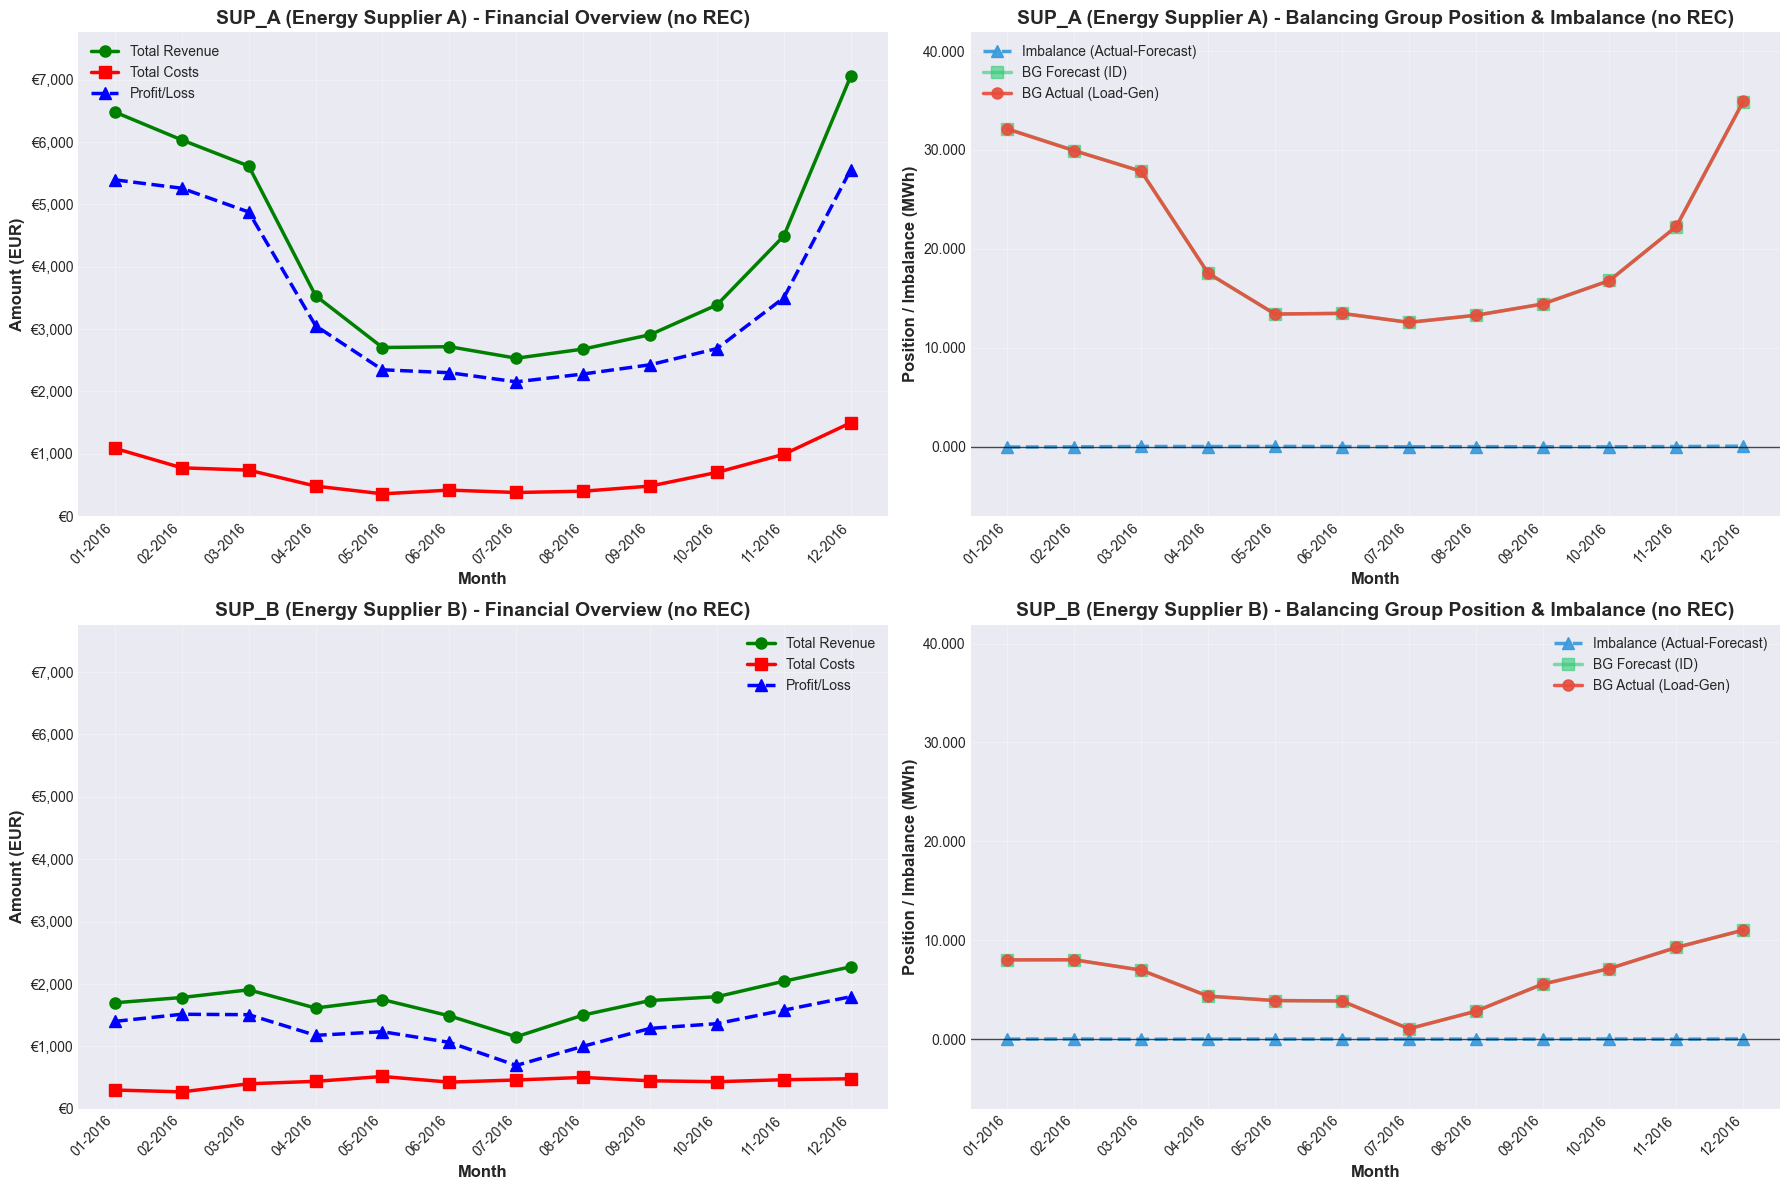

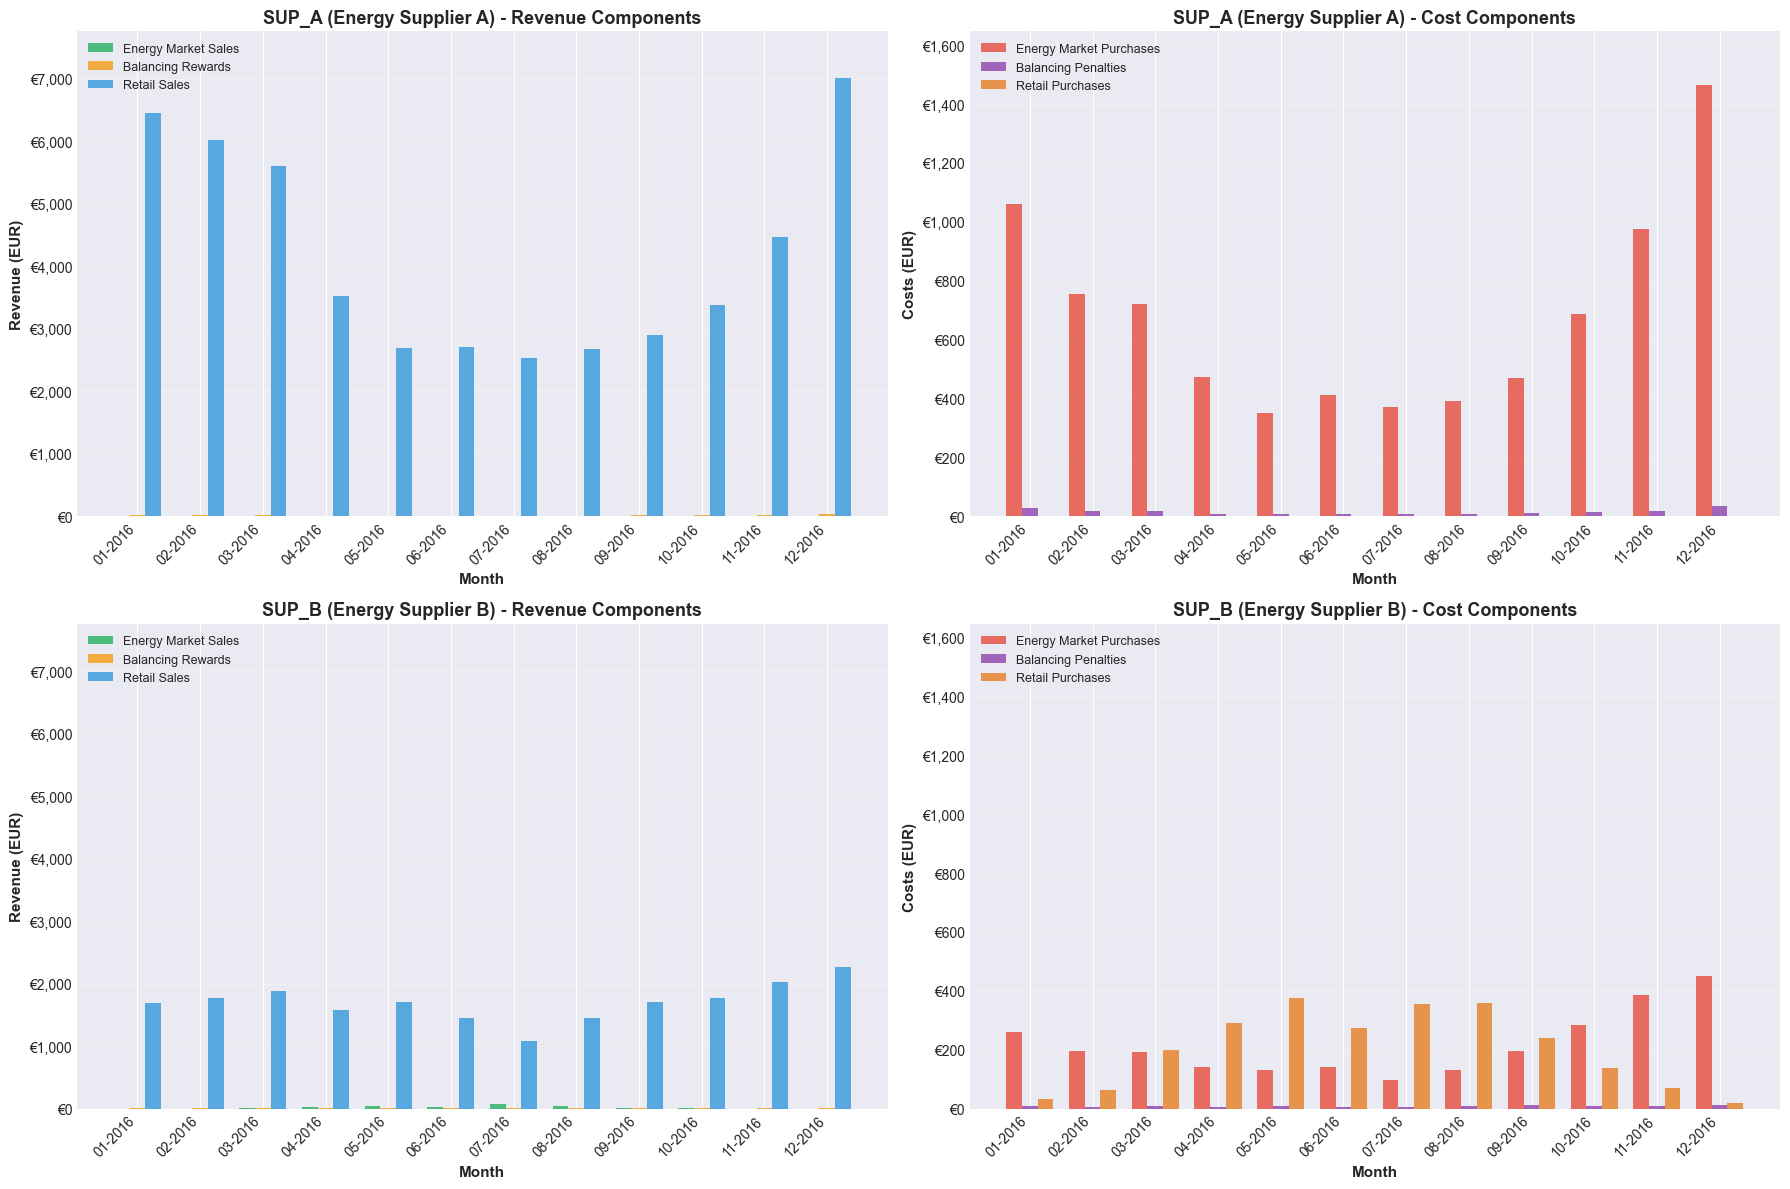


ANNUAL FINANCIAL SUMMARY

SUP_A (Energy Supplier A):

  REVENUES:
    Energy Market Sales:    €0.00
    Balancing Rewards:      €176.78
    Retail Sales:           €49,958.69
    ──────────────────────────────────────
    Total Revenue:          €50,135.47

  COSTS:
    Energy Market Purchases: €8,128.50
    Balancing Penalties:     €177.18
    Retail Purchases:        €0.00
    ──────────────────────────────────────
    Total Costs:             €8,305.68

  PROFIT/LOSS:
    Annual Total:            €41,829.79
    Monthly Average:         €3,485.82
    Monthly Min:             €2,153.64
    Monthly Max:             €5,556.02

  IMBALANCE STATISTICS:
    System Position:         SHORT (Deficit)
                             (Actual deficit > forecast, need to buy more)
    Actual BG Position:      248.55 MWh
    Avg Monthly Actual:      20.71 MWh
    Max Monthly Actual:      34.91 MWh
    Forecast BG Position:    248.50 MWh
    Avg Monthly Forecast:    20.71 MWh
    Max Monthly Forecast

In [94]:
# Plot monthly financial analysis for both suppliers with SAME SCALES
import matplotlib.pyplot as plt
import numpy as np

# Net imbalance already calculated as imbalance_mwh
# For backward compatibility, create alias
es_monthly_df_analysis['net_imbalance_mwh'] = es_monthly_df_analysis['imbalance_mwh']

# Create supplier name mapping from config
supplier_names = {s['supplier_id']: s['supplier_name'] for s in config['suppliers']}

# Calculate global min/max for consistent scales
all_data = es_monthly_df_analysis[es_monthly_df_analysis['supplier_id'].isin(['SUP_A', 'SUP_B'])]

# Financial overview limits
max_revenue = all_data['total_revenue_eur'].max()
max_costs = all_data['total_costs_eur'].max()
min_profit = all_data['profit_loss_eur'].min()
max_profit = all_data['profit_loss_eur'].max()
financial_ylim = [min(min_profit * 1.1, 0), max(max_revenue, max_costs, max_profit) * 1.1]

# Imbalance limits (combined for both suppliers)
all_imbalances = np.concatenate([
    all_data['balancing_group_actual_mwh'].values,
    all_data['balancing_group_forecast_mwh'].values,
    all_data['imbalance_mwh'].values
])
imb_min = all_imbalances.min()
imb_max = all_imbalances.max()
imb_margin = (imb_max - imb_min) * 0.2
imbalance_ylim = [imb_min - imb_margin, imb_max + imb_margin]

# Prepare data for plotting - 2 subplots per supplier
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot for each supplier
for idx, supplier in enumerate(['SUP_A', 'SUP_B']):
    # Filter data for this supplier
    supplier_data = es_monthly_df_analysis[es_monthly_df_analysis['supplier_id'] == supplier].copy()
    
    # Get supplier display name
    supplier_display = f"{supplier} ({supplier_names[supplier]})"
    
    # Sort by datetime for proper line plot
    supplier_data = supplier_data.sort_values('datetime')
    
    # Create x-axis positions
    x_pos = range(len(supplier_data))
    
    # Plot 1: Financial overview (revenue, costs, profit/loss) - SAME SCALE
    ax1 = axes[idx, 0]
    ax1.plot(x_pos, supplier_data['total_revenue_eur'], marker='o', linewidth=2.5, 
            label='Total Revenue', color='green', markersize=8)
    ax1.plot(x_pos, supplier_data['total_costs_eur'], marker='s', linewidth=2.5, 
            label='Total Costs', color='red', markersize=8)
    ax1.plot(x_pos, supplier_data['profit_loss_eur'], marker='^', linewidth=2.5, 
            label='Profit/Loss', color='blue', markersize=8, linestyle='--')
    
    # Add horizontal line at zero
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
    
    # Formatting for plot 1 with SAME Y-AXIS
    ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Amount (EUR)', fontsize=12, fontweight='bold')
    ax1.set_title(f'{supplier_display} - Financial Overview (no REC)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(supplier_data['datetime'].values, rotation=45, ha='right')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax1.set_ylim(financial_ylim)  # SAME SCALE FOR BOTH
    
    # Plot 2: Balancing Group Position & Imbalance - SAME SCALE
    ax2 = axes[idx, 1]
    
    # Plot all three values on same scale for direct comparison with transparency
    ax2.plot(x_pos, supplier_data['imbalance_mwh'], marker='^', linewidth=2.5, 
            label='Imbalance (Actual-Forecast)', color='#3498db', markersize=8, linestyle='--', alpha=0.9)
    ax2.plot(x_pos, supplier_data['balancing_group_forecast_mwh'], marker='s', linewidth=2.5, 
            label='BG Forecast (ID)', color='#2ecc71', markersize=8, alpha=0.6)
    ax2.plot(x_pos, supplier_data['balancing_group_actual_mwh'], marker='o', linewidth=2.5, 
            label='BG Actual (Load-Gen)', color='#e74c3c', markersize=8, alpha=0.9)
    
    # Add horizontal line at zero
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    
    # Formatting for plot 2 with SAME Y-AXIS
    ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Position / Imbalance (MWh)', fontsize=12, fontweight='bold')
    ax2.set_title(f'{supplier_display} - Balancing Group Position & Imbalance (no REC)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(supplier_data['datetime'].values, rotation=45, ha='right')
    ax2.legend(loc='best', fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.3f}'))
    ax2.set_ylim(imbalance_ylim)  # SAME SCALE FOR BOTH

plt.tight_layout()
plt.show()

# Grouped bar chart for revenue and cost components with SAME SCALES (side by side)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Calculate global max for revenue and cost scales
max_revenue_stack = all_data.groupby(['datetime', 'supplier_id']).agg({
    'revenue_energy_market_sales_eur': 'sum',
    'revenue_balancing_rewards_eur': 'sum',
    'revenue_retail_sales_eur': 'sum'
}).sum(axis=1).max()

max_cost_stack = all_data.groupby(['datetime', 'supplier_id']).agg({
    'cost_energy_market_purchases_eur': 'sum',
    'cost_balancing_penalties_eur': 'sum',
    'cost_retail_purchases_eur': 'sum'
}).sum(axis=1).max()

revenue_ylim = [0, max_revenue_stack * 1.1]
cost_ylim = [0, max_cost_stack * 1.1]

for idx, supplier in enumerate(['SUP_A', 'SUP_B']):
    supplier_data = es_monthly_df_analysis[es_monthly_df_analysis['supplier_id'] == supplier].copy()
    supplier_data = supplier_data.sort_values('datetime')
    n_months = len(supplier_data)
    
    # Get supplier display name
    supplier_display = f"{supplier} ({supplier_names[supplier]})"
    
    # Revenue breakdown with SIDE-BY-SIDE bars
    ax_rev = axes[idx, 0]
    revenue_components = [
        supplier_data['revenue_energy_market_sales_eur'].values,
        supplier_data['revenue_balancing_rewards_eur'].values,
        supplier_data['revenue_retail_sales_eur'].values
    ]
    labels_rev = ['Energy Market Sales', 'Balancing Rewards', 'Retail Sales']
    colors_rev = ['#27ae60', '#f39c12', '#3498db']  # Dark green, orange, blue
    
    # Bar width and positions for grouped bars
    bar_width = 0.25
    x_pos = np.arange(n_months)
    
    for i, (component, label, color) in enumerate(zip(revenue_components, labels_rev, colors_rev)):
        offset = (i - 1) * bar_width  # Center the groups
        ax_rev.bar(x_pos + offset, component, width=bar_width, label=label, color=color, alpha=0.8)
    
    ax_rev.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax_rev.set_ylabel('Revenue (EUR)', fontsize=11, fontweight='bold')
    ax_rev.set_title(f'{supplier_display} - Revenue Components', fontsize=13, fontweight='bold')
    ax_rev.set_xticks(x_pos)
    ax_rev.set_xticklabels(supplier_data['datetime'].values, rotation=45, ha='right')
    ax_rev.legend(loc='upper left', fontsize=9)
    ax_rev.grid(True, alpha=0.3, axis='y')
    ax_rev.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax_rev.set_ylim(revenue_ylim)  # SAME SCALE FOR BOTH
    
    # Cost breakdown with SIDE-BY-SIDE bars
    ax_cost = axes[idx, 1]
    cost_components = [
        supplier_data['cost_energy_market_purchases_eur'].values,
        supplier_data['cost_balancing_penalties_eur'].values,
        supplier_data['cost_retail_purchases_eur'].values
    ]
    labels_cost = ['Energy Market Purchases', 'Balancing Penalties', 'Retail Purchases']
    colors_cost = ['#e74c3c', '#8e44ad', '#e67e22']  # Red, purple, orange
    
    for i, (component, label, color) in enumerate(zip(cost_components, labels_cost, colors_cost)):
        offset = (i - 1) * bar_width  # Center the groups
        ax_cost.bar(x_pos + offset, component, width=bar_width, label=label, color=color, alpha=0.8)
    
    ax_cost.set_xlabel('Month', fontsize=11, fontweight='bold')
    ax_cost.set_ylabel('Costs (EUR)', fontsize=11, fontweight='bold')
    ax_cost.set_title(f'{supplier_display} - Cost Components', fontsize=13, fontweight='bold')
    ax_cost.set_xticks(x_pos)
    ax_cost.set_xticklabels(supplier_data['datetime'].values, rotation=45, ha='right')
    ax_cost.legend(loc='upper left', fontsize=9)
    ax_cost.grid(True, alpha=0.3, axis='y')
    ax_cost.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'€{x:,.0f}'))
    ax_cost.set_ylim(cost_ylim)  # SAME SCALE FOR BOTH

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("ANNUAL FINANCIAL SUMMARY")
print("="*80)

for supplier in ['SUP_A', 'SUP_B']:
    supplier_data = es_monthly_df_analysis[es_monthly_df_analysis['supplier_id'] == supplier].copy()
    supplier_display = f"{supplier} ({supplier_names[supplier]})"
    
    print(f"\n{supplier_display}:")
    print(f"\n  REVENUES:")
    print(f"    Energy Market Sales:    €{supplier_data['revenue_energy_market_sales_eur'].sum():,.2f}")
    print(f"    Balancing Rewards:      €{supplier_data['revenue_balancing_rewards_eur'].sum():,.2f}")
    print(f"    Retail Sales:           €{supplier_data['revenue_retail_sales_eur'].sum():,.2f}")
    print(f"    ──────────────────────────────────────")
    print(f"    Total Revenue:          €{supplier_data['total_revenue_eur'].sum():,.2f}")
    
    print(f"\n  COSTS:")
    print(f"    Energy Market Purchases: €{supplier_data['cost_energy_market_purchases_eur'].sum():,.2f}")
    print(f"    Balancing Penalties:     €{supplier_data['cost_balancing_penalties_eur'].sum():,.2f}")
    print(f"    Retail Purchases:        €{supplier_data['cost_retail_purchases_eur'].sum():,.2f}")
    print(f"    ──────────────────────────────────────")
    print(f"    Total Costs:             €{supplier_data['total_costs_eur'].sum():,.2f}")
    
    print(f"\n  PROFIT/LOSS:")
    print(f"    Annual Total:            €{supplier_data['profit_loss_eur'].sum():,.2f}")
    print(f"    Monthly Average:         €{supplier_data['profit_loss_eur'].mean():,.2f}")
    print(f"    Monthly Min:             €{supplier_data['profit_loss_eur'].min():,.2f}")
    print(f"    Monthly Max:             €{supplier_data['profit_loss_eur'].max():,.2f}")
    
    # Imbalance statistics
    print(f"\n  IMBALANCE STATISTICS:")
    
    # Determine system position based on imbalance
    total_imb = supplier_data['imbalance_mwh'].sum()
    if total_imb > 0:
        position = "SHORT (Deficit)"
        position_desc = "Actual deficit > forecast, need to buy more"
    elif total_imb < 0:
        position = "LONG (Surplus)"
        position_desc = "Actual deficit < forecast, have surplus to sell"
    else:
        position = "BALANCED"
        position_desc = "Actual matched forecast exactly"
    
    print(f"    System Position:         {position}")
    print(f"                             ({position_desc})")
    print(f"    Actual BG Position:      {supplier_data['balancing_group_actual_mwh'].sum():,.2f} MWh")
    print(f"    Avg Monthly Actual:      {supplier_data['balancing_group_actual_mwh'].mean():,.2f} MWh")
    print(f"    Max Monthly Actual:      {abs(supplier_data['balancing_group_actual_mwh']).max():,.2f} MWh")
    print(f"    Forecast BG Position:    {supplier_data['balancing_group_forecast_mwh'].sum():,.2f} MWh")
    print(f"    Avg Monthly Forecast:    {supplier_data['balancing_group_forecast_mwh'].mean():,.2f} MWh")
    print(f"    Max Monthly Forecast:    {abs(supplier_data['balancing_group_forecast_mwh']).max():,.2f} MWh")
    print(f"    Total Imbalance:         {supplier_data['imbalance_mwh'].sum():,.2f} MWh")
    print(f"    Avg Monthly Imbalance:   {supplier_data['imbalance_mwh'].mean():,.2f} MWh")
    print(f"    Max Monthly Imbalance:   {abs(supplier_data['imbalance_mwh']).max():,.2f} MWh")

In [95]:
# Investigate SUP_B retail purchase costs in detail
print("="*80)
print("DETAILED ANALYSIS: SUP_B RETAIL PURCHASE COSTS")
print("="*80)

# Get SUP_B customer data
sup_b_customers = customer_billing_df[customer_billing_df['supplier_id'] == 'SUP_B'].copy()

# Aggregate by customer
customer_summary = sup_b_customers.groupby('customer_id').agg({
    'actual_load_mwh': 'sum',
    'actual_gen_mwh': 'sum',
    'purchase_costs_eur': 'sum'
}).round(2)

customer_summary['grid_export_mwh'] = (customer_summary['actual_gen_mwh'] - customer_summary['actual_load_mwh']).clip(lower=0)

print("\nSUP_B Prosumer Summary (Annual):")
print(customer_summary)

print(f"\n{'='*80}")
print("FEED-IN PRICE CHECK:")
print(f"{'='*80}")
print(f"Fixed Feed-in Price: €{es_data['prices']['feedin_price'].mean():.2f}/MWh")
print(f"\nTotal Annual Export (SUP_B): {customer_summary['grid_export_mwh'].sum():.2f} MWh")
print(f"Expected Cost: {customer_summary['grid_export_mwh'].sum():.2f} MWh × €{es_data['prices']['feedin_price'].mean():.2f}/MWh = €{customer_summary['grid_export_mwh'].sum() * es_data['prices']['feedin_price'].mean():.2f}")
print(f"Actual Total Cost: €{customer_summary['purchase_costs_eur'].sum():.2f}")
print(f"\nDifference: €{abs(customer_summary['purchase_costs_eur'].sum() - customer_summary['grid_export_mwh'].sum() * es_data['prices']['feedin_price'].mean()):.2f}")

# Check if there's an issue with aggregation
print(f"\n{'='*80}")
print("MONTHLY AGGREGATION CHECK:")
print(f"{'='*80}")
sup_b_monthly = es_monthly_df_analysis[es_monthly_df_analysis['supplier_id'] == 'SUP_B'][['datetime', 'purchase_costs_eur']]
print(sup_b_monthly)
print(f"\nSum of monthly values: €{sup_b_monthly['purchase_costs_eur'].sum():.2f}")

DETAILED ANALYSIS: SUP_B RETAIL PURCHASE COSTS

SUP_B Prosumer Summary (Annual):
              actual_load_mwh  actual_gen_mwh  purchase_costs_eur  \
customer_id                                                         
prosumer_001            92.83            5.02                0.70   
prosumer_002             9.78           17.47             1203.00   
prosumer_003             9.78           17.86             1208.84   

              grid_export_mwh  
customer_id                    
prosumer_001             0.00  
prosumer_002             7.69  
prosumer_003             8.08  

FEED-IN PRICE CHECK:
Fixed Feed-in Price: €82.40/MWh

Total Annual Export (SUP_B): 15.77 MWh
Expected Cost: 15.77 MWh × €82.40/MWh = €1299.45
Actual Total Cost: €2412.54

Difference: €1113.09

MONTHLY AGGREGATION CHECK:
   datetime  purchase_costs_eur
1   01-2016           31.051918
3   02-2016           64.842626
5   03-2016          197.687902
7   04-2016          289.468372
9   05-2016          375.501217
